In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_fscore_support,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans as SklearnKMeans, AgglomerativeClustering
from sklearn.neural_network import MLPClassifier
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("../engineered_nyc.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (11491, 21)


,Fiscal_Year,Borough,Award,Council_District_num,Sector_Community & Culture,Sector_Education,Sector_Environment,Sector_General Admin,Sector_Health & Human Svcs,Sector_Housing & Dev,...,Sector_Transportation,Categ_Arts & Culture,Categ_Community/Housing,Categ_Education,Categ_Healthcare,Categ_Infrastructure/Renovation,Categ_Parks & Recreation,Categ_Safety/Security,Categ_Technology,Other
0,2019,X,250000,16.0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
1,2019,K,3640000,37.0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,0
2,2019,M,425000,5.0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
3,2019,M,100000,5.0,0,1,0,0,0,0,...,0,0,0,1,0,1,1,0,0,0
4,2019,M,35000,5.0,0,1,0,0,0,0,...,0,0,0,1,0,1,0,0,1,0


In [3]:
df.isna().sum()

Fiscal_Year                         0
Borough                             0
Award                               0
Council_District_num               26
Sector_Community & Culture          0
Sector_Education                    0
Sector_Environment                  0
Sector_General Admin                0
Sector_Health & Human Svcs          0
Sector_Housing & Dev                0
Sector_Public Safety                0
Sector_Transportation               0
Categ_Arts & Culture                0
Categ_Community/Housing             0
Categ_Education                     0
Categ_Healthcare                    0
Categ_Infrastructure/Renovation     0
Categ_Parks & Recreation            0
Categ_Safety/Security               0
Categ_Technology                    0
Other                               0
dtype: int64

In [4]:
print(df['Award'].max())
print(df['Award'].min())
print(df['Award'].mean())
print(df['Award'].median())

15800000
10000
530864.850752763
172000.0


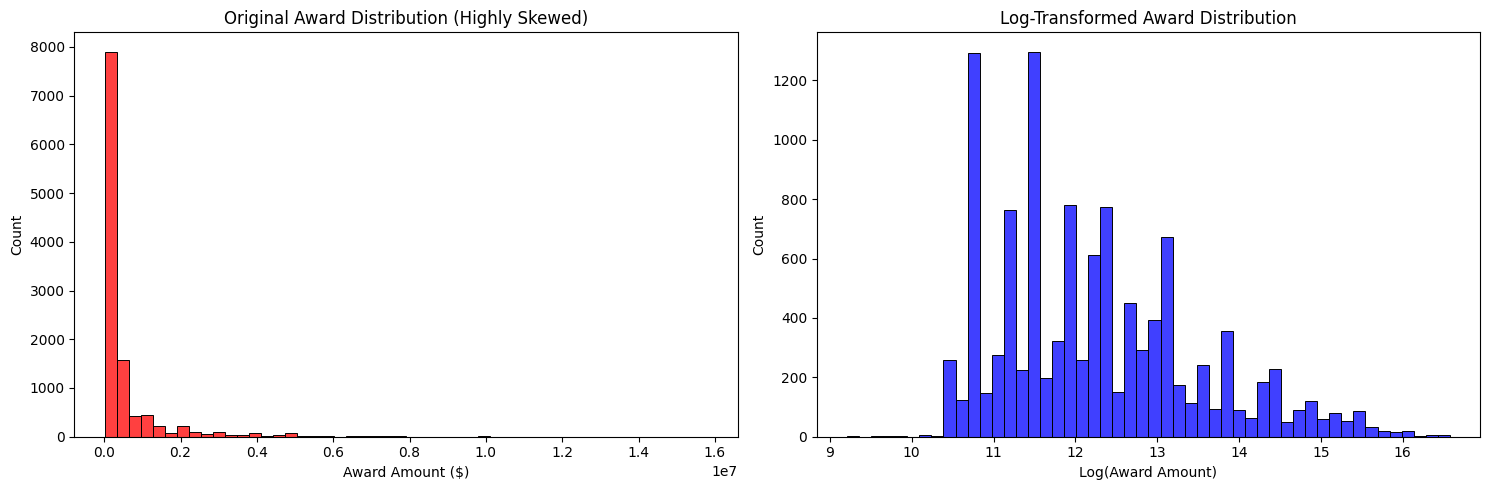

In [5]:
#plotting before vs after log transformation

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['Award'], bins=50, ax=axes[0], color='red')
axes[0].set_title('Original Award Distribution (Highly Skewed)')
axes[0].set_xlabel('Award Amount ($)')

sns.histplot(np.log1p(df['Award']), bins=50, ax=axes[1], color='blue')
axes[1].set_title('Log-Transformed Award Distribution')
axes[1].set_xlabel('Log(Award Amount)')

plt.tight_layout()
plt.show()

==========

Create Funding Level Labels (Target Variable)

==========

In [6]:
# Create 5 funding level bins based on Award distribution within each Fiscal Year
def create_funding_levels(df, award_col="Award", year_col="Fiscal_Year"):
    labels = ["low", "mid-low", "mid", "mid-high", "high"]

    def _per_year(group):
        if group[award_col].nunique() < 5:
            ranks = group[award_col].rank(method="first")
            group["Funding_Level"] = pd.qcut(
                ranks, q=min(5, len(group)),
                labels=labels[:min(5, len(group))]
            )
        else:
            ranks = group[award_col].rank(method="first")
            group["Funding_Level"] = pd.qcut(ranks, q=5, labels=labels)
        return group

    df = df.copy()
    df = df.dropna(subset=[award_col, year_col])
    # Preserve year_col: groupby can drop it in newer pandas
    saved_year = df[year_col].copy()
    df = df.groupby(year_col, group_keys=False).apply(_per_year)
    if year_col not in df.columns:
        df[year_col] = saved_year
    return df


df = create_funding_levels(df)
df = df.dropna(subset=["Funding_Level"])

print("Funding Level distribution:")
print(df["Funding_Level"].value_counts())

Funding Level distribution:
Funding_Level
low         2303
high        2298
mid-high    2297
mid-low     2297
mid         2296
Name: count, dtype: int64


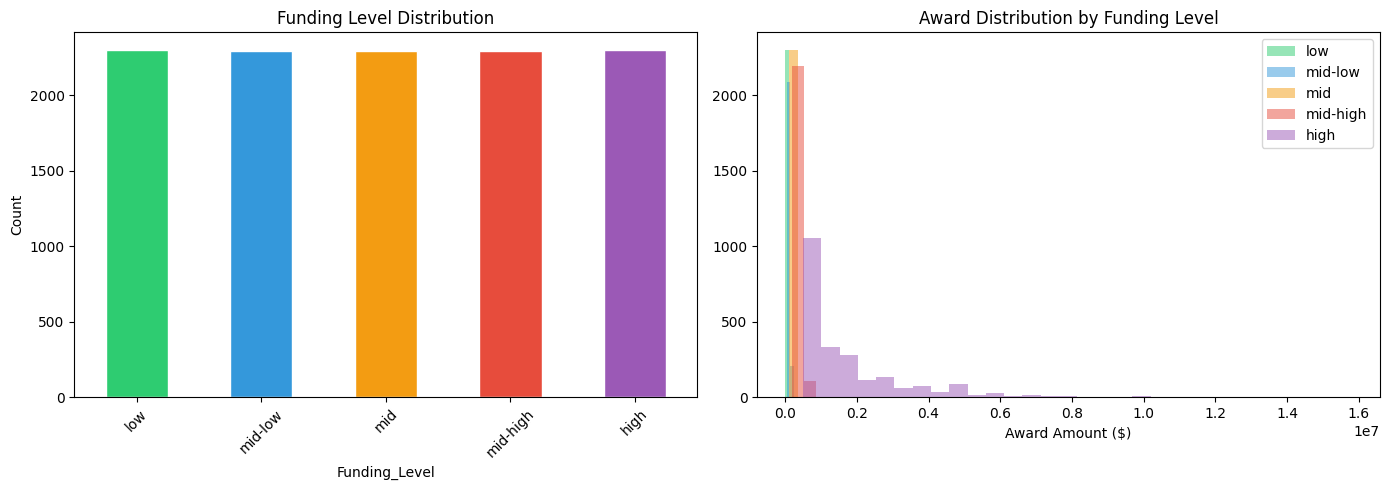

In [7]:
# Visualize Funding Level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = ["low", "mid-low", "mid", "mid-high", "high"]
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6']

df["Funding_Level"].value_counts().reindex(order).plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='white'
)
axes[0].set_title('Funding Level Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(order, rotation=45)

for level, color in zip(order, colors):
    subset = df[df['Funding_Level'] == level]['Award']
    axes[1].hist(subset, bins=30, alpha=0.5, label=level, color=color)
axes[1].set_title('Award Distribution by Funding Level')
axes[1].set_xlabel('Award Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

==========

Train Test Splitting - encoding and scaling for classification

==========

In [8]:
def encode_labels(y):
    """Convert Funding_Level strings to integers 0..K-1."""
    unique_labels = sorted(y.dropna().unique().tolist())
    label_to_int = {label: idx for idx, label in enumerate(unique_labels)}
    int_to_label = {idx: label for label, idx in label_to_int.items()}
    y_int = y.map(label_to_int).astype(int)
    return y_int, label_to_int, int_to_label


# Fix corrupted Council_District_num (NYC has 51 districts max)
df["Council_District_num"] = df["Council_District_num"].clip(upper=51)

# One-hot encode Borough if it's still a string column
if not pd.api.types.is_numeric_dtype(df["Borough"]):
    borough_dummies = pd.get_dummies(df["Borough"], prefix="Borough")
    df = pd.concat([df, borough_dummies], axis=1)

# Select feature columns
feature_cols = ["Fiscal_Year", "Council_District_num"]
sector_cols = [c for c in df.columns if c.startswith("Sector_")]
categ_cols = [c for c in df.columns if c.startswith("Categ_")]
borough_cols = [c for c in df.columns if c.startswith("Borough_")]
feature_cols.extend(sector_cols + categ_cols + borough_cols)
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy().fillna(0)
y_int, label_to_int, int_to_label = encode_labels(df["Funding_Level"])
class_names = [int_to_label[i] for i in sorted(int_to_label)]
num_classes = len(class_names)

print(f"Features used: {len(feature_cols)}")
print(f"Feature list: {feature_cols}")
print(f"Classes: {label_to_int}")
print(f"Dataset size: {X.shape}")

Features used: 24
Feature list: ['Fiscal_Year', 'Council_District_num', 'Sector_Community & Culture', 'Sector_Education', 'Sector_Environment', 'Sector_General Admin', 'Sector_Health & Human Svcs', 'Sector_Housing & Dev', 'Sector_Public Safety', 'Sector_Transportation', 'Categ_Arts & Culture', 'Categ_Community/Housing', 'Categ_Education', 'Categ_Healthcare', 'Categ_Infrastructure/Renovation', 'Categ_Parks & Recreation', 'Categ_Safety/Security', 'Categ_Technology', 'Borough_A', 'Borough_K', 'Borough_M', 'Borough_Q', 'Borough_R', 'Borough_X']
Classes: {'high': 0, 'low': 1, 'mid': 2, 'mid-high': 3, 'mid-low': 4}
Dataset size: (11491, 24)


In [9]:
# Scaling with Yeo-Johnson (generalized Box-Cox) instead of StandardScaler
# Yeo-Johnson handles zero and negative values, transforms to Gaussian-like
scaler = PowerTransformer(method='yeo-johnson', standardize=True)
X_scaled = scaler.fit_transform(X.values)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_int.values,
    test_size=0.2, random_state=42, stratify=y_int.values
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (test):  {np.bincount(y_test)}")

Training set: 9192 samples
Test set:     2299 samples
Class distribution (train): [1838 1842 1837 1837 1838]
Class distribution (test):  [460 461 459 460 459]


In [10]:
# Check for missing or infinite values
print("Total NaNs in X_train:", np.isnan(X_train).sum())
print("Total Infs in X_train:", np.isinf(X_train).sum())
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

Total NaNs in X_train: 0
Total Infs in X_train: 0
X_train shape: (9192, 24)
y_train shape: (9192,)


In [11]:
# Dictionary to store results for final benchmarking
results = {}


def evaluate_model(name, y_true, y_pred, y_proba=None, show_plots=True):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )
    
    cm = confusion_matrix(y_true, y_pred)
    
    # Specificity (per class, then average)
    specificities = []
    for i in range(num_classes):
        tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
        fp = np.sum(cm[:, i]) - cm[i, i]
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(specificity)
    avg_specificity = np.mean(specificities)
    
    # ROC-AUC
    auc_score = None
    if y_proba is not None:
        try:
            y_test_bin = label_binarize(y_true, classes=list(range(num_classes)))
            auc_score = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')
        except Exception:
            auc_score = None
    
    results[name] = {
        'Accuracy': acc,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'Specificity (TNR)': avg_specificity,
        'F1-Score': f1,
        'ROC-AUC': auc_score
    }
    
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Accuracy:              {acc:.4f}")
    print(f"  Precision (weighted):  {precision:.4f}")
    print(f"  Recall/Sensitivity:    {recall:.4f}")
    print(f"  Specificity (TNR):     {avg_specificity:.4f}")
    print(f"  F1-Score (weighted):   {f1:.4f}")
    if auc_score is not None:
        print(f"  ROC-AUC (macro):       {auc_score:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    
    if show_plots:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
            ax=axes[0], cmap='Blues', colorbar=False
        )
        axes[0].set_title(f'{name} - Confusion Matrix')
        
        if y_proba is not None:
            y_test_bin = label_binarize(y_true, classes=list(range(num_classes)))
            for i in range(num_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                roc_auc_i = auc(fpr, tpr)
                axes[1].plot(fpr, tpr, label=f'{class_names[i]} (AUC={roc_auc_i:.2f})')
            axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
            axes[1].set_xlabel('False Positive Rate')
            axes[1].set_ylabel('True Positive Rate')
            axes[1].set_title(f'{name} - ROC Curves (One-vs-Rest)')
            axes[1].legend(fontsize=8)
        else:
            axes[1].text(0.5, 0.5, 'No probability\nestimates available',
                        ha='center', va='center', fontsize=14)
            axes[1].set_title(f'{name} - ROC Curves')
        
        plt.tight_layout()
        plt.show()
    
    return results[name]

==========

Logistic regression

==========

- From Scratch (Softmax Regression)

In [12]:
class SoftmaxRegression:

    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.W = None
        self.b = None
        self.loss_history = []

    @staticmethod
    def _softmax(Z):
        Z_shift = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    @staticmethod
    def _one_hot(y, num_classes):
        N = y.shape[0]
        one_hot = np.zeros((N, num_classes))
        one_hot[np.arange(N), y] = 1
        return one_hot

    def _cross_entropy_loss(self, probs, y_one_hot):
        N = probs.shape[0]
        log_probs = -np.log(np.clip(probs, 1e-12, 1.0))
        loss = np.sum(y_one_hot * log_probs) / N
        return loss

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        N, d = X.shape
        num_classes = len(np.unique(y))

        self.W = np.zeros((d, num_classes))
        self.b = np.zeros((1, num_classes))
        y_one_hot = self._one_hot(y, num_classes)
        self.loss_history = []

        for i in range(self.n_iters):
            logits = X.dot(self.W) + self.b
            probs = self._softmax(logits)

            if i % 50 == 0:
                loss = self._cross_entropy_loss(probs, y_one_hot)
                self.loss_history.append(loss)

            grad_logits = (probs - y_one_hot) / N
            grad_W = X.T.dot(grad_logits)
            grad_b = np.sum(grad_logits, axis=0, keepdims=True)

            self.W -= self.lr * grad_W
            self.b -= self.lr * grad_b

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        logits = X.dot(self.W) + self.b
        return self._softmax(logits)

    def predict(self, X):
        probs = self.predict_proba(X)
        return np.argmax(probs, axis=1)


  Softmax Regression (Scratch)
  Accuracy:              0.4093
  Precision (weighted):  0.3886
  Recall/Sensitivity:    0.4093
  Specificity (TNR):     0.8523
  F1-Score (weighted):   0.3849
  ROC-AUC (macro):       0.7319

Classification Report:
              precision    recall  f1-score   support

        high       0.49      0.61      0.54       460
         low       0.45      0.67      0.54       461
         mid       0.27      0.14      0.18       459
    mid-high       0.34      0.38      0.36       460
     mid-low       0.39      0.25      0.30       459

    accuracy                           0.41      2299
   macro avg       0.39      0.41      0.38      2299
weighted avg       0.39      0.41      0.38      2299



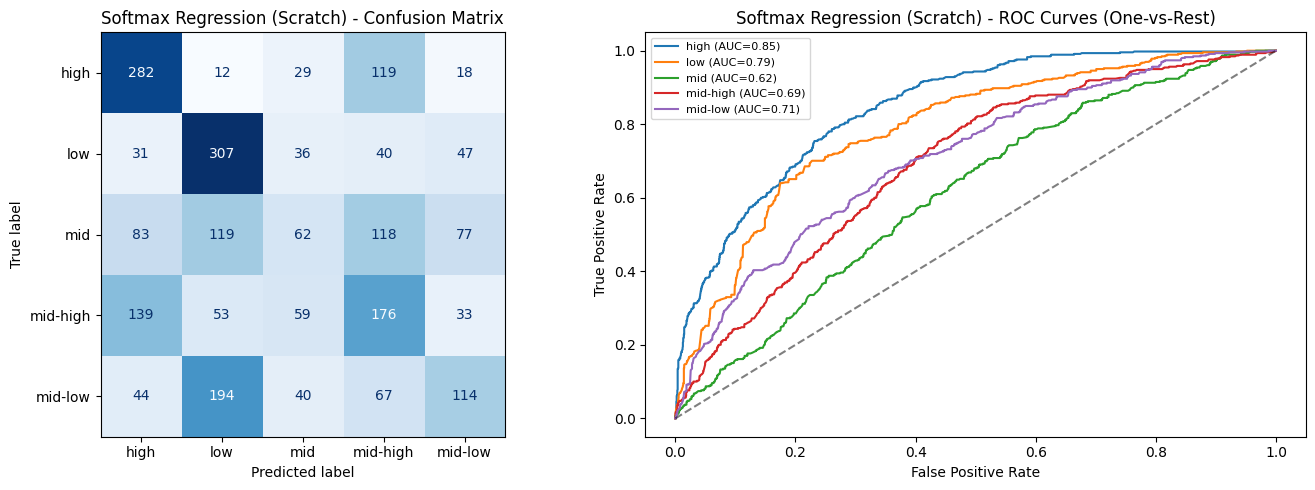

{'Accuracy': 0.40930839495432797,
 'Precision': 0.3885696803415877,
 'Recall (Sensitivity)': 0.40930839495432797,
 'Specificity (TNR)': np.float64(0.8523087091686972),
 'F1-Score': 0.38491400051576785,
 'ROC-AUC': 0.7319173581800723}

In [13]:
softmax_model = SoftmaxRegression(lr=0.05, n_iters=5000)
softmax_model.fit(X_train, y_train)

y_pred_softmax = softmax_model.predict(X_test)
y_proba_softmax = softmax_model.predict_proba(X_test)

evaluate_model("Softmax Regression (Scratch)", y_test, y_pred_softmax, y_proba_softmax)

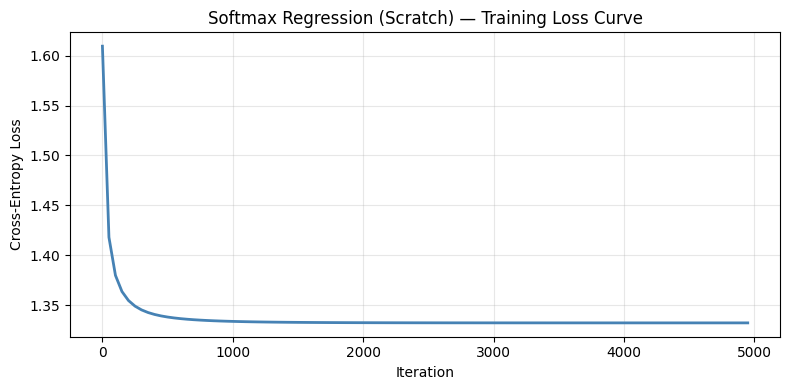

In [14]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(0, len(softmax_model.loss_history) * 50, 50),
         softmax_model.loss_history, color='steelblue', linewidth=2)
plt.title('Softmax Regression (Scratch) — Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Using sklearn lib


  Logistic Regression (Sklearn)
  Accuracy:              0.4093
  Precision (weighted):  0.3886
  Recall/Sensitivity:    0.4093
  Specificity (TNR):     0.8523
  F1-Score (weighted):   0.3849
  ROC-AUC (macro):       0.7319

Classification Report:
              precision    recall  f1-score   support

        high       0.49      0.61      0.54       460
         low       0.45      0.67      0.54       461
         mid       0.27      0.14      0.18       459
    mid-high       0.34      0.38      0.36       460
     mid-low       0.39      0.25      0.30       459

    accuracy                           0.41      2299
   macro avg       0.39      0.41      0.38      2299
weighted avg       0.39      0.41      0.38      2299



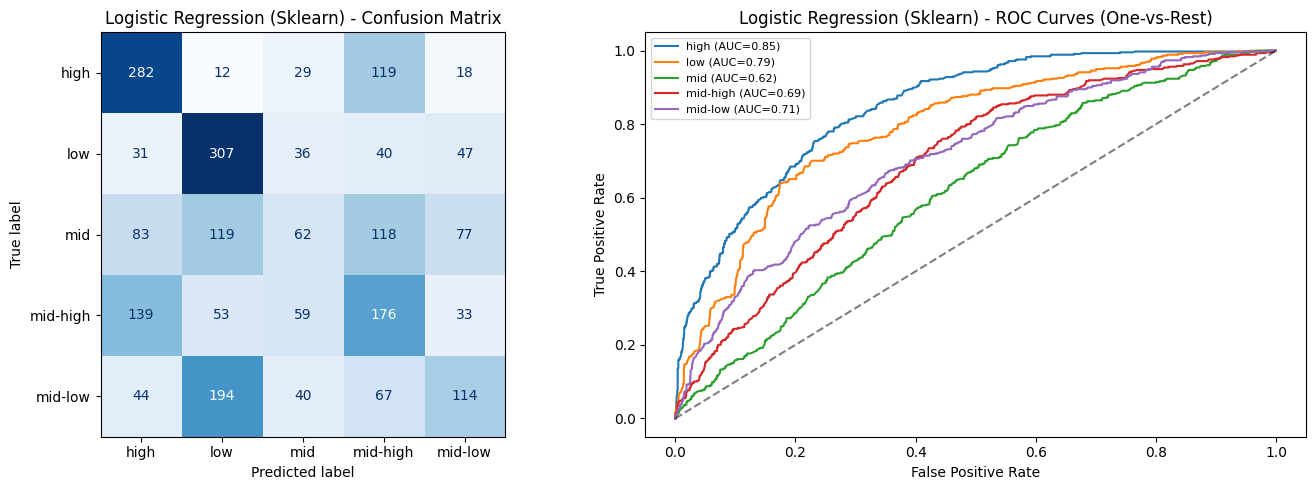

{'Accuracy': 0.40930839495432797,
 'Precision': 0.3885696803415877,
 'Recall (Sensitivity)': 0.40930839495432797,
 'Specificity (TNR)': np.float64(0.8523087091686972),
 'F1-Score': 0.38491400051576785,
 'ROC-AUC': 0.7319220726715656}

In [15]:
sk_logreg = LogisticRegression(
    solver='lbfgs', max_iter=300, C=0.5, random_state=42
)
sk_logreg.fit(X_train, y_train)

y_pred_sklr = sk_logreg.predict(X_test)
y_proba_sklr = sk_logreg.predict_proba(X_test)

evaluate_model("Logistic Regression (Sklearn)", y_test, y_pred_sklr, y_proba_sklr)

==========

Decision tree

==========

- From Scratch (Gini Impurity)

In [16]:
class DecisionTreeScratch:

    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

    def __init__(self, max_depth=10, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.n_classes = None

    def _gini(self, y):
        if len(y) == 0:
            return 0
        counts = np.bincount(y, minlength=self.n_classes)
        probs = counts / len(y)
        return 1 - np.sum(probs ** 2)

    def _best_split(self, X, y):
        best_gain = -1
        best_feature, best_threshold = None, None
        parent_gini = self._gini(y)
        n = len(y)

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            if len(thresholds) > 50:
                thresholds = np.percentile(X[:, feature], np.linspace(0, 100, 50))

            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask

                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                left_gini = self._gini(y[left_mask])
                right_gini = self._gini(y[right_mask])

                weighted_gini = (
                    np.sum(left_mask) / n * left_gini +
                    np.sum(right_mask) / n * right_gini
                )
                gain = parent_gini - weighted_gini

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        if (depth >= self.max_depth or
            len(y) < self.min_samples_split or
            len(np.unique(y)) == 1):
            leaf_value = np.bincount(y, minlength=self.n_classes).argmax()
            return self.Node(value=leaf_value)

        feature, threshold = self._best_split(X, y)
        if feature is None:
            leaf_value = np.bincount(y, minlength=self.n_classes).argmax()
            return self.Node(value=leaf_value)

        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask

        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return self.Node(feature=feature, threshold=threshold,
                         left=left_child, right=right_child)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y, dtype=int)
        self.n_classes = len(np.unique(y))
        self.root = self._build_tree(X, y)

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.root) for x in X])


  Decision Tree (Scratch)
  Accuracy:              0.4676
  Precision (weighted):  0.4628
  Recall/Sensitivity:    0.4676
  Specificity (TNR):     0.8669
  F1-Score (weighted):   0.4633

Classification Report:
              precision    recall  f1-score   support

        high       0.53      0.57      0.55       460
         low       0.60      0.69      0.64       461
         mid       0.35      0.36      0.36       459
    mid-high       0.34      0.32      0.33       460
     mid-low       0.49      0.40      0.44       459

    accuracy                           0.47      2299
   macro avg       0.46      0.47      0.46      2299
weighted avg       0.46      0.47      0.46      2299



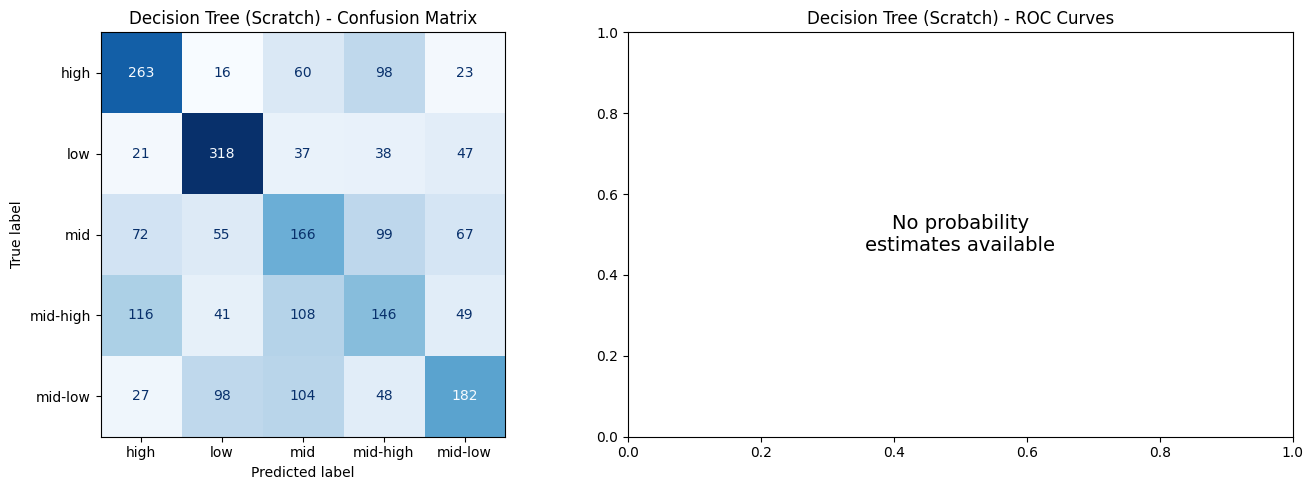

{'Accuracy': 0.4675946063505872,
 'Precision': 0.46283453216078446,
 'Recall (Sensitivity)': 0.4675946063505872,
 'Specificity (TNR)': np.float64(0.8669010078427991),
 'F1-Score': 0.4632603496483091,
 'ROC-AUC': None}

In [17]:
dt_scratch = DecisionTreeScratch(max_depth=20, min_samples_split=2)
dt_scratch.fit(X_train, y_train)

y_pred_dt_scratch = dt_scratch.predict(X_test)

evaluate_model("Decision Tree (Scratch)", y_test, y_pred_dt_scratch)

- Using sklearn lib


  Decision Tree (Sklearn)
  Accuracy:              0.4424
  Precision (weighted):  0.4501
  Recall/Sensitivity:    0.4424
  Specificity (TNR):     0.8606
  F1-Score (weighted):   0.4420
  ROC-AUC (macro):       0.7579

Classification Report:
              precision    recall  f1-score   support

        high       0.59      0.66      0.62       460
         low       0.57      0.53      0.55       461
         mid       0.28      0.37      0.32       459
    mid-high       0.38      0.35      0.36       460
     mid-low       0.43      0.31      0.36       459

    accuracy                           0.44      2299
   macro avg       0.45      0.44      0.44      2299
weighted avg       0.45      0.44      0.44      2299



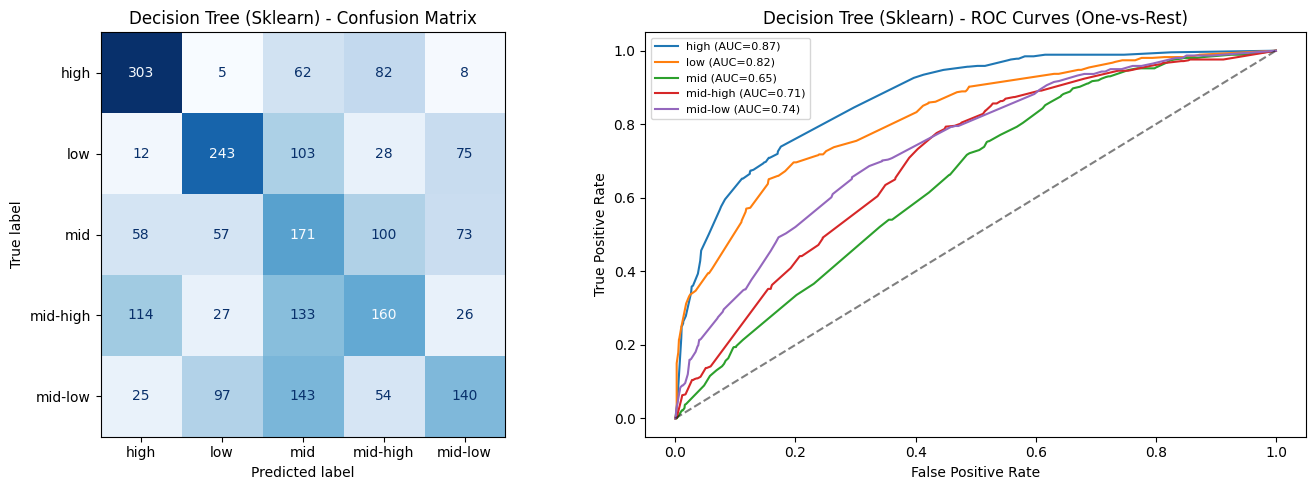

{'Accuracy': 0.4423662461939974,
 'Precision': 0.45008810773273417,
 'Recall (Sensitivity)': 0.4423662461939974,
 'Specificity (TNR)': np.float64(0.8606022175098763),
 'F1-Score': 0.4420064055792702,
 'ROC-AUC': 0.7579447534063447}

In [18]:
sk_dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)
sk_dt.fit(X_train, y_train)

y_pred_skdt = sk_dt.predict(X_test)
y_proba_skdt = sk_dt.predict_proba(X_test)

evaluate_model("Decision Tree (Sklearn)", y_test, y_pred_skdt, y_proba_skdt)

==========

Ensemble learning: Random Forest

==========

- From Scratch (Bagging + Decision Trees)

In [19]:
class RandomForestScratch:

    def __init__(self, n_estimators=50, max_depth=10, min_samples_split=5,
                 max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.feature_indices = []
        self.n_classes = None

    def _get_max_features(self, n_features):
        if self.max_features == 'sqrt':
            return max(1, int(np.sqrt(n_features)))
        elif self.max_features == 'log2':
            return max(1, int(np.log2(n_features)))
        elif isinstance(self.max_features, int):
            return min(self.max_features, n_features)
        else:
            return n_features

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))
        max_feat = self._get_max_features(n_features)

        rng = np.random.RandomState(self.random_state)
        self.trees = []
        self.feature_indices = []

        for _ in range(self.n_estimators):
            # Bootstrap sample
            boot_idx = rng.choice(n_samples, size=n_samples, replace=True)
            X_boot = X[boot_idx]
            y_boot = y[boot_idx]

            # Random feature subset
            feat_idx = np.sort(rng.choice(n_features, size=max_feat, replace=False))
            X_boot_sub = X_boot[:, feat_idx]

            tree = DecisionTreeScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split
            )
            tree.fit(X_boot_sub, y_boot)

            self.trees.append(tree)
            self.feature_indices.append(feat_idx)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        all_preds = np.zeros((X.shape[0], self.n_classes))

        for tree, feat_idx in zip(self.trees, self.feature_indices):
            preds = tree.predict(X[:, feat_idx])
            for i, p in enumerate(preds):
                all_preds[i, p] += 1

        return np.argmax(all_preds, axis=1)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        all_preds = np.zeros((X.shape[0], self.n_classes))

        for tree, feat_idx in zip(self.trees, self.feature_indices):
            preds = tree.predict(X[:, feat_idx])
            for i, p in enumerate(preds):
                all_preds[i, p] += 1

        row_sums = all_preds.sum(axis=1, keepdims=True)
        return all_preds / row_sums


  Random Forest (Scratch)
  Accuracy:              0.3267
  Precision (weighted):  0.3981
  Recall/Sensitivity:    0.3267
  Specificity (TNR):     0.8316
  F1-Score (weighted):   0.2171
  ROC-AUC (macro):       0.7058

Classification Report:
              precision    recall  f1-score   support

        high       0.43      0.70      0.53       460
         low       0.27      0.85      0.41       461
         mid       0.35      0.03      0.05       459
    mid-high       0.44      0.03      0.06       460
     mid-low       0.50      0.02      0.03       459

    accuracy                           0.33      2299
   macro avg       0.40      0.33      0.22      2299
weighted avg       0.40      0.33      0.22      2299



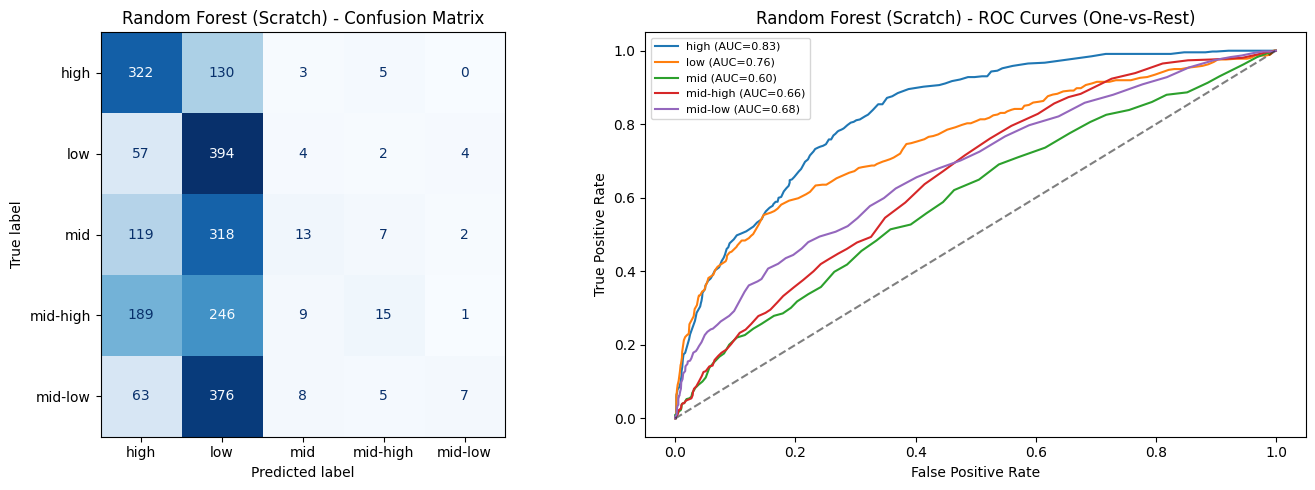

{'Accuracy': 0.3266637668551544,
 'Precision': 0.3981173205588962,
 'Recall (Sensitivity)': 0.3266637668551544,
 'Specificity (TNR)': np.float64(0.8315861547917682),
 'F1-Score': 0.2171024035899611,
 'ROC-AUC': 0.7058323298112027}

In [20]:
rf_scratch = RandomForestScratch(
    n_estimators=200, max_depth=18, min_samples_split=2,
    max_features='sqrt', random_state=42
)
rf_scratch.fit(X_train, y_train)

y_pred_rf_scratch = rf_scratch.predict(X_test)
y_proba_rf_scratch = rf_scratch.predict_proba(X_test)

evaluate_model("Random Forest (Scratch)", y_test, y_pred_rf_scratch, y_proba_rf_scratch)

- Using sklearn lib


  Random Forest (Sklearn)
  Accuracy:              0.4489
  Precision (weighted):  0.4305
  Recall/Sensitivity:    0.4489
  Specificity (TNR):     0.8622
  F1-Score (weighted):   0.4290
  ROC-AUC (macro):       0.7651

Classification Report:
              precision    recall  f1-score   support

        high       0.56      0.69      0.62       460
         low       0.51      0.66      0.57       461
         mid       0.26      0.15      0.19       459
    mid-high       0.36      0.44      0.40       460
     mid-low       0.47      0.30      0.37       459

    accuracy                           0.45      2299
   macro avg       0.43      0.45      0.43      2299
weighted avg       0.43      0.45      0.43      2299



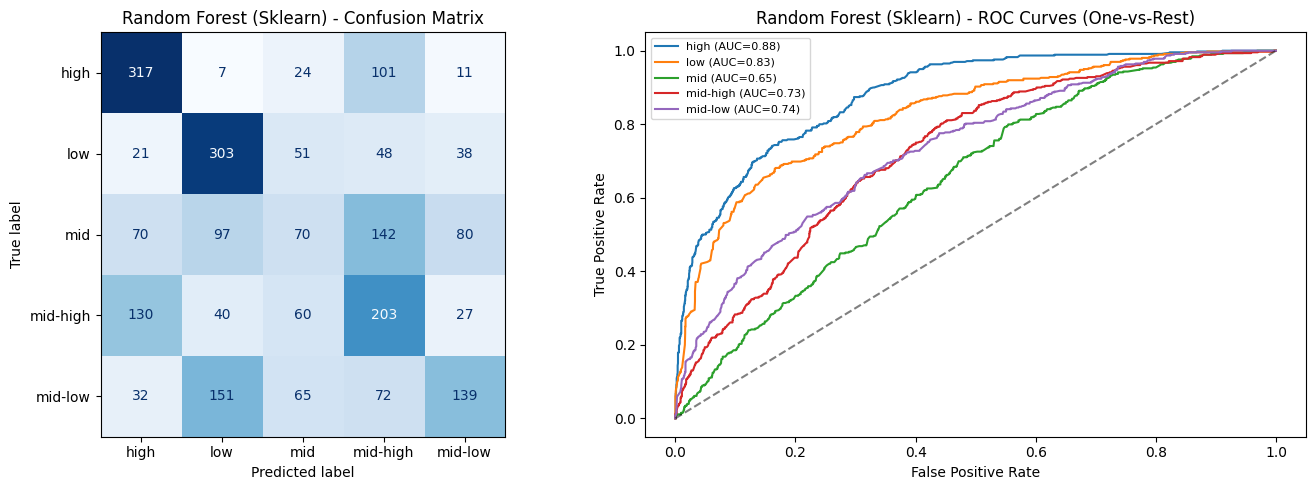

{'Accuracy': 0.4488908220965637,
 'Precision': 0.4304763296521557,
 'Recall (Sensitivity)': 0.4488908220965637,
 'Specificity (TNR)': np.float64(0.8622113080714302),
 'F1-Score': 0.42903705573372314,
 'ROC-AUC': 0.7650582440270528}

In [21]:
rf_clf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1
)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)

evaluate_model("Random Forest (Sklearn)", y_test, y_pred_rf, y_proba_rf)

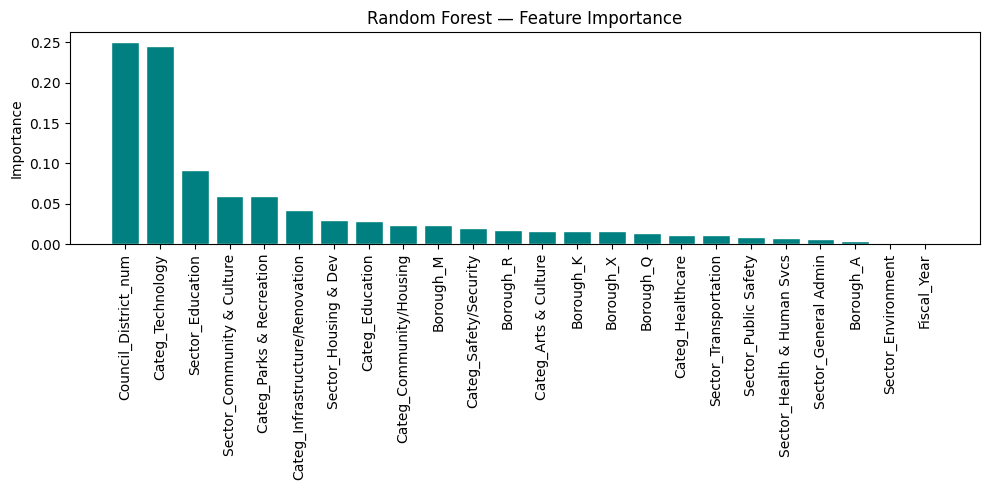

In [22]:
# Feature Importance
importances = rf_clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[sorted_idx], color='teal', edgecolor='white')
plt.xticks(range(len(importances)), [feature_cols[i] for i in sorted_idx], rotation=90)
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

==========

Support vector machine

==========

- From Scratch


  SVM From Scratch (OvR Linear)
  Accuracy:              0.3693
  Precision (weighted):  0.3642
  Recall/Sensitivity:    0.3693
  Specificity (TNR):     0.8423
  F1-Score (weighted):   0.3305
  ROC-AUC (macro):       0.6712

Classification Report:
              precision    recall  f1-score   support

        high       0.48      0.63      0.55       460
         low       0.44      0.65      0.52       461
         mid       0.22      0.14      0.17       459
    mid-high       0.43      0.07      0.12       460
     mid-low       0.25      0.35      0.29       459

    accuracy                           0.37      2299
   macro avg       0.36      0.37      0.33      2299
weighted avg       0.36      0.37      0.33      2299



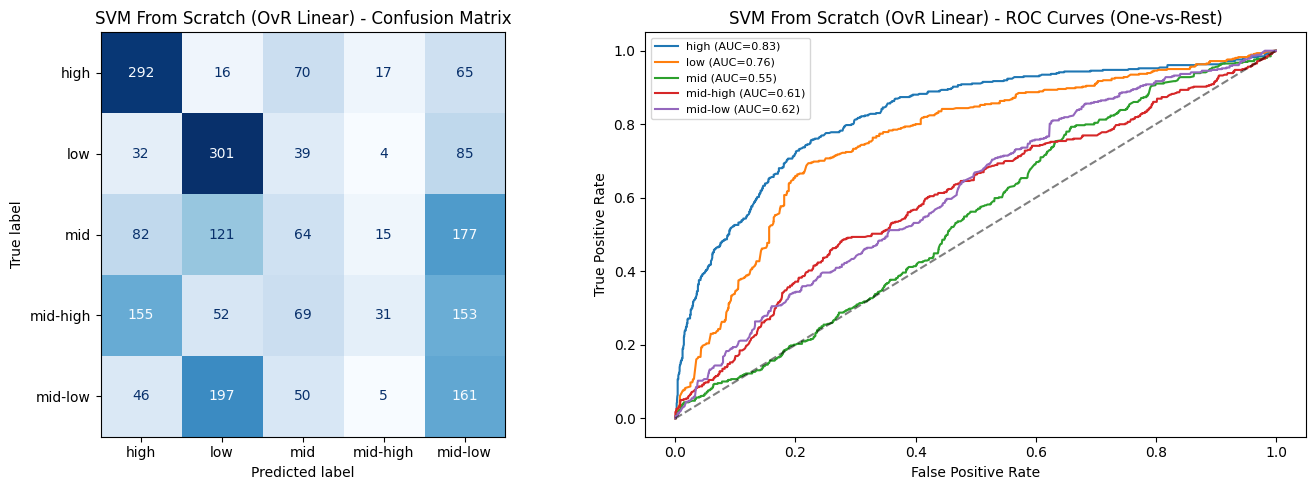

{'Accuracy': 0.36929099608525445,
 'Precision': 0.3641633023696783,
 'Recall (Sensitivity)': 0.36929099608525445,
 'Specificity (TNR)': np.float64(0.8423246081269496),
 'F1-Score': 0.3304557441138924,
 'ROC-AUC': 0.6712064085283431}

In [23]:
class SVMScratch:
    """
    Support Vector Machine — Multiclass via One-vs-Rest.
    Each binary classifier uses linear kernel with hinge loss + SGD.
    OvR scores are z-scored (calibrated on training data) so that
    classifiers with different scales are comparable for argmax / softmax.
    """

    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.classifiers = {}  # {class_label: (w, b)}

    def _fit_binary(self, X, y):
        """Train one binary SVM (y in {-1, +1})."""
        n_samples, n_features = X.shape
        w = np.zeros(n_features)
        b = 0.0
        rng = np.random.RandomState(42)
        for epoch in range(self.n_iters):
            indices = rng.permutation(n_samples)  # shuffle each epoch
            for i in indices:
                margin = y[i] * (X[i].dot(w) + b)
                if margin >= 1:
                    w -= self.lr * (2 * self.lambda_param * w)
                else:
                    w -= self.lr * (2 * self.lambda_param * w - y[i] * X[i])
                    b -= self.lr * (-y[i])
        return w, b

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for c in self.classes_:
            y_binary = np.where(y == c, 1, -1)
            w, b = self._fit_binary(X, y_binary)
            self.classifiers[c] = (w, b)
        # Calibrate: z-score each OvR classifier's output so all
        # scores are on the same scale (each binary SVM may learn
        # weights of very different magnitude → raw scores not comparable).
        raw = self._raw_scores(X)
        self._cal_mean = raw.mean(axis=0)
        self._cal_std = raw.std(axis=0)
        self._cal_std[self._cal_std < 1e-10] = 1.0
        return self

    def _raw_scores(self, X):
        """Un-calibrated OvR decision-function values."""
        scores = np.zeros((X.shape[0], len(self.classes_)))
        for idx, c in enumerate(self.classes_):
            w, b = self.classifiers[c]
            scores[:, idx] = X.dot(w) + b
        return scores

    def decision_function(self, X):
        """Calibrated decision-function values (z-scored per classifier)."""
        return (self._raw_scores(X) - self._cal_mean) / self._cal_std

    def predict(self, X):
        scores = self.decision_function(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_proba(self, X):
        scores = self.decision_function(X)
        # softmax on calibrated scores → proper pseudo-probabilities
        exp_scores = np.exp(scores - np.max(scores, axis=1, keepdims=True))
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)


# --- Train & Evaluate SVM From Scratch ---
sample_idx = np.random.RandomState(42).choice(len(X_train), size=min(5000, len(X_train)), replace=False)
X_train_sample = X_train[sample_idx]
y_train_sample = y_train[sample_idx]

svm_scratch = SVMScratch(lr=0.001, lambda_param=0.001, n_iters=500)
svm_scratch.fit(X_train_sample, y_train_sample)

y_pred_svm_scratch = svm_scratch.predict(X_test)
y_proba_svm_scratch = svm_scratch.predict_proba(X_test)

evaluate_model("SVM From Scratch (OvR Linear)", y_test, y_pred_svm_scratch, y_proba_svm_scratch)

- Using sklearn lib


  SVM (Sklearn)
  Accuracy:              0.3971
  Precision (weighted):  0.3977
  Recall/Sensitivity:    0.3971
  Specificity (TNR):     0.8493
  F1-Score (weighted):   0.3448
  ROC-AUC (macro):       0.7029

Classification Report:
              precision    recall  f1-score   support

        high       0.44      0.65      0.52       460
         low       0.45      0.66      0.53       461
         mid       0.32      0.03      0.06       459
    mid-high       0.30      0.49      0.37       460
     mid-low       0.48      0.15      0.23       459

    accuracy                           0.40      2299
   macro avg       0.40      0.40      0.34      2299
weighted avg       0.40      0.40      0.34      2299



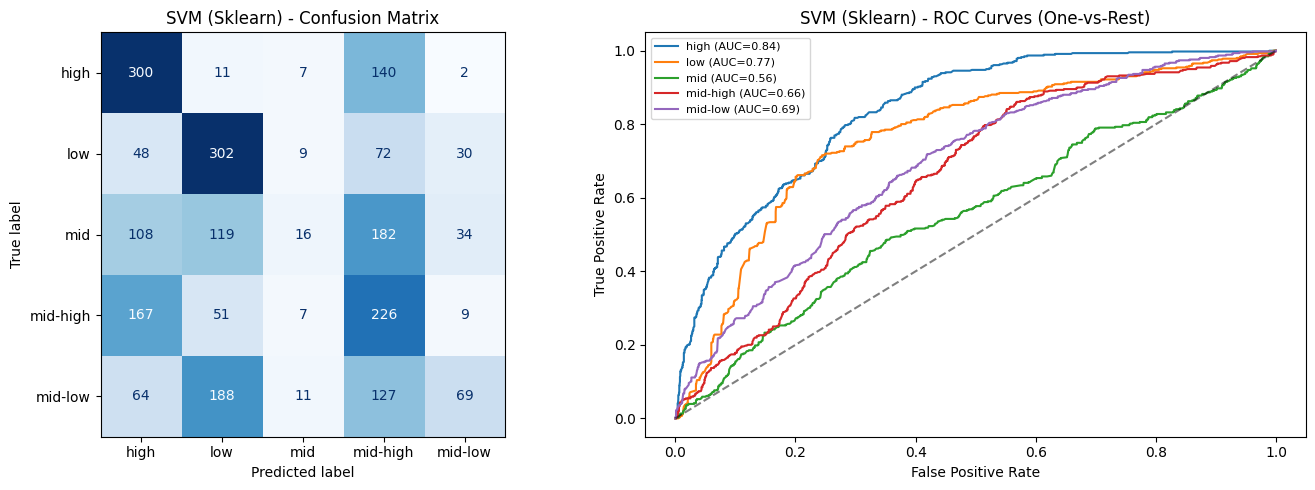

{'Accuracy': 0.39712918660287083,
 'Precision': 0.3977143225516119,
 'Recall (Sensitivity)': 0.39712918660287083,
 'Specificity (TNR)': np.float64(0.8492505141308252),
 'F1-Score': 0.34483086267902685,
 'ROC-AUC': 0.7029088312416102}

In [24]:
svm_clf = SVC(kernel='linear', C=0.5, probability=True, random_state=42)
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)
y_proba_svm = svm_clf.predict_proba(X_test)

evaluate_model("SVM (Sklearn)", y_test, y_pred_svm, y_proba_svm)

==========

Dimensionality reduction for random forest/support vector machine

==========

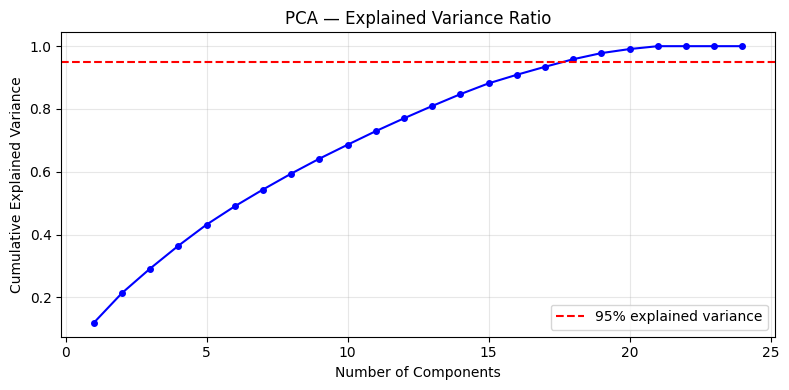


Using 18 PCA components (explains >=95% variance)


In [25]:
# Determine number of components that explain 95% variance
pca_full = PCA().fit(X_train)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar) + 1), cumvar, 'bo-', markersize=4)
plt.axhline(0.95, color='r', linestyle='--', label='95% explained variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Explained Variance Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n_components = np.argmax(cumvar >= 0.95) + 1
print(f"\nUsing {n_components} PCA components (explains >=95% variance)")

In [26]:
# Apply PCA
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original features: {X_train.shape[1]} -> PCA features: {X_train_pca.shape[1]}")

Original features: 24 -> PCA features: 18



  Random Forest + PCA
  Accuracy:              0.4511
  Precision (weighted):  0.4466
  Recall/Sensitivity:    0.4511
  Specificity (TNR):     0.8628
  F1-Score (weighted):   0.4484
  ROC-AUC (macro):       0.7446

Classification Report:
              precision    recall  f1-score   support

        high       0.57      0.62      0.59       460
         low       0.60      0.60      0.60       461
         mid       0.31      0.29      0.30       459
    mid-high       0.36      0.37      0.36       460
     mid-low       0.40      0.37      0.39       459

    accuracy                           0.45      2299
   macro avg       0.45      0.45      0.45      2299
weighted avg       0.45      0.45      0.45      2299



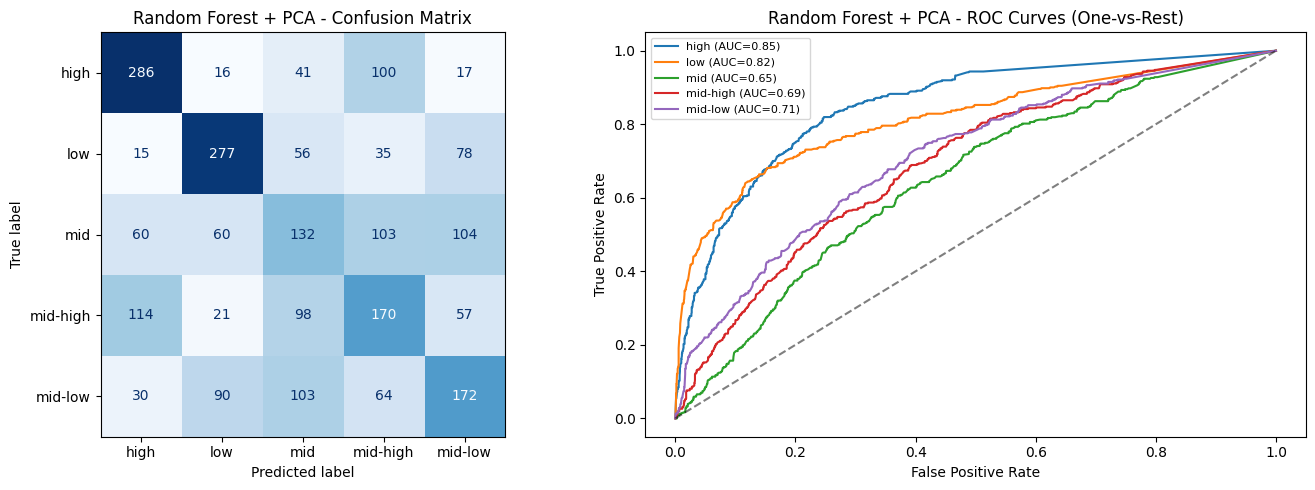

{'Accuracy': 0.4510656807307525,
 'Precision': 0.44661250057312324,
 'Recall (Sensitivity)': 0.4510656807307525,
 'Specificity (TNR)': np.float64(0.8627731751967016),
 'F1-Score': 0.44840940781517075,
 'ROC-AUC': 0.7445525154602841}

In [27]:
# Random Forest with PCA
rf_pca = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca = rf_pca.predict(X_test_pca)
y_proba_rf_pca = rf_pca.predict_proba(X_test_pca)

evaluate_model("Random Forest + PCA", y_test, y_pred_rf_pca, y_proba_rf_pca)


  SVM + PCA
  Accuracy:              0.4197
  Precision (weighted):  0.4027
  Recall/Sensitivity:    0.4197
  Specificity (TNR):     0.8549
  F1-Score (weighted):   0.3996
  ROC-AUC (macro):       0.7266

Classification Report:
              precision    recall  f1-score   support

        high       0.47      0.64      0.54       460
         low       0.49      0.63      0.55       461
         mid       0.28      0.15      0.20       459
    mid-high       0.34      0.39      0.36       460
     mid-low       0.43      0.29      0.34       459

    accuracy                           0.42      2299
   macro avg       0.40      0.42      0.40      2299
weighted avg       0.40      0.42      0.40      2299



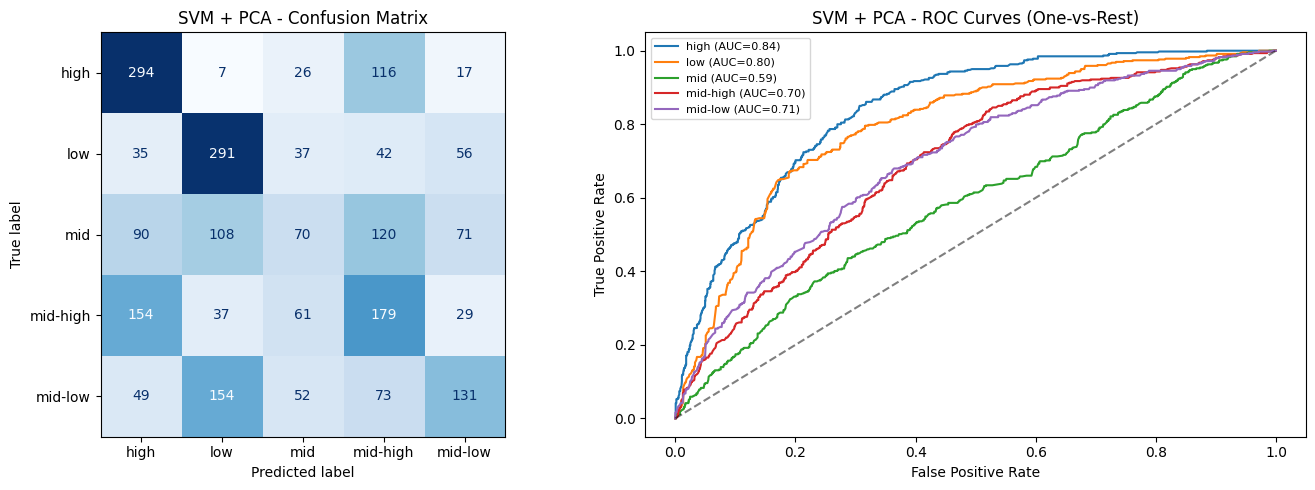

{'Accuracy': 0.4197477163984341,
 'Precision': 0.4027391062497521,
 'Recall (Sensitivity)': 0.4197477163984341,
 'Specificity (TNR)': np.float64(0.8549236746713348),
 'F1-Score': 0.39959961577695674,
 'ROC-AUC': 0.7265803481989994}

In [28]:
# SVM with PCA
svm_pca = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_pca.fit(X_train_pca, y_train)

y_pred_svm_pca = svm_pca.predict(X_test_pca)
y_proba_svm_pca = svm_pca.predict_proba(X_test_pca)

evaluate_model("SVM + PCA", y_test, y_pred_svm_pca, y_proba_svm_pca)

==========

Unsupervised k-mean and agglomerative clustering

==========

- K-Means from Scratch

In [29]:
class KMeansScratch:

    def __init__(self, n_clusters=5, max_iters=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels_ = None
        self.inertia_ = None

    def fit(self, X):
        np.random.seed(self.random_state)
        X = np.asarray(X, dtype=float)
        n_samples = X.shape[0]

        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[indices].copy()

        for _ in range(self.max_iters):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            labels = np.argmin(distances, axis=1)

            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.sum(labels == k) > 0
                else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            if np.allclose(self.centroids, new_centroids):
                break
            self.centroids = new_centroids

        self.labels_ = labels
        self.inertia_ = np.sum((X - self.centroids[labels]) ** 2)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

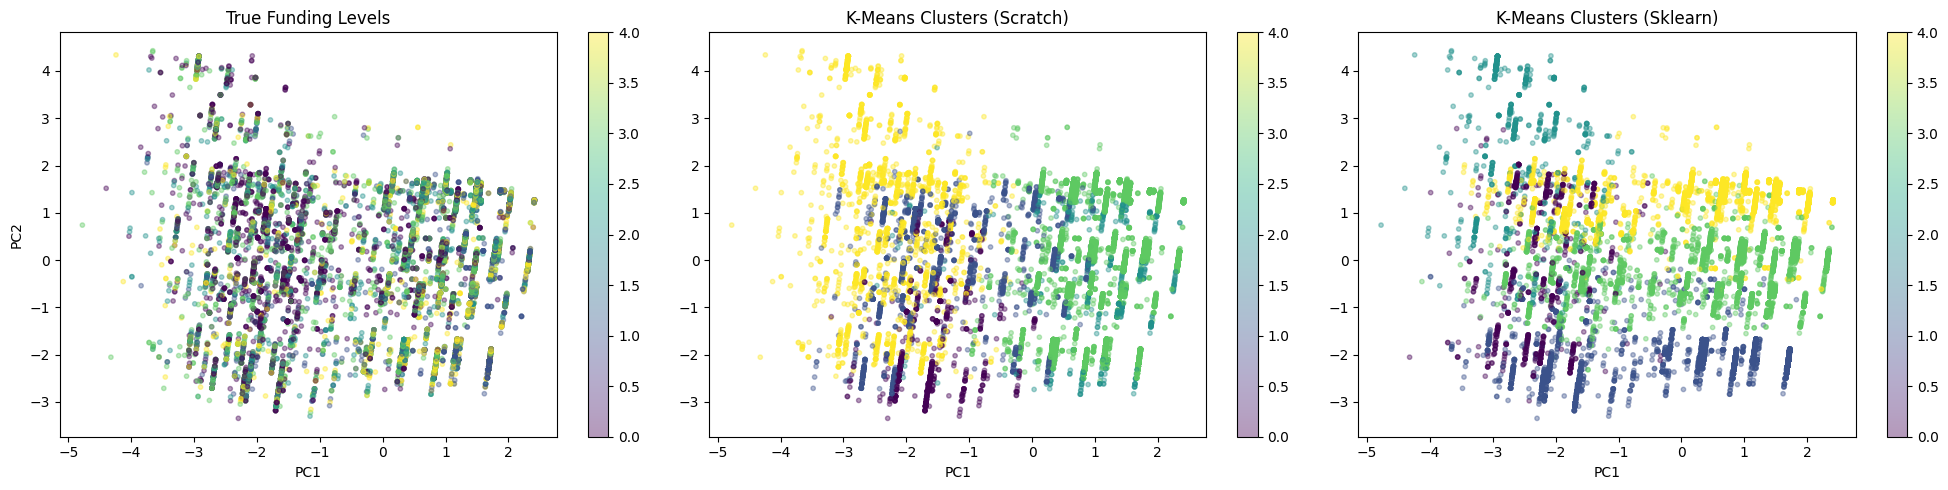

K-Means (Scratch) Inertia: 208389.88
K-Means (Sklearn) Inertia: 194749.23


In [30]:
# K-Means from scratch
kmeans_scratch = KMeansScratch(n_clusters=5, max_iters=300, random_state=42)
kmeans_scratch.fit(X_scaled)

# K-Means sklearn
kmeans_sk = SklearnKMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_sk.fit(X_scaled)

# Visualize clusters using PCA for 2D projection
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

scatter0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_int.values, cmap='viridis', alpha=0.4, s=10)
axes[0].set_title('True Funding Levels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter0, ax=axes[0])

scatter1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_scratch.labels_, cmap='viridis', alpha=0.4, s=10)
axes[1].set_title('K-Means Clusters (Scratch)')
axes[1].set_xlabel('PC1')
plt.colorbar(scatter1, ax=axes[1])

scatter2 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans_sk.labels_, cmap='viridis', alpha=0.4, s=10)
axes[2].set_title('K-Means Clusters (Sklearn)')
axes[2].set_xlabel('PC1')
plt.colorbar(scatter2, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"K-Means (Scratch) Inertia: {kmeans_scratch.inertia_:.2f}")
print(f"K-Means (Sklearn) Inertia: {kmeans_sk.inertia_:.2f}")

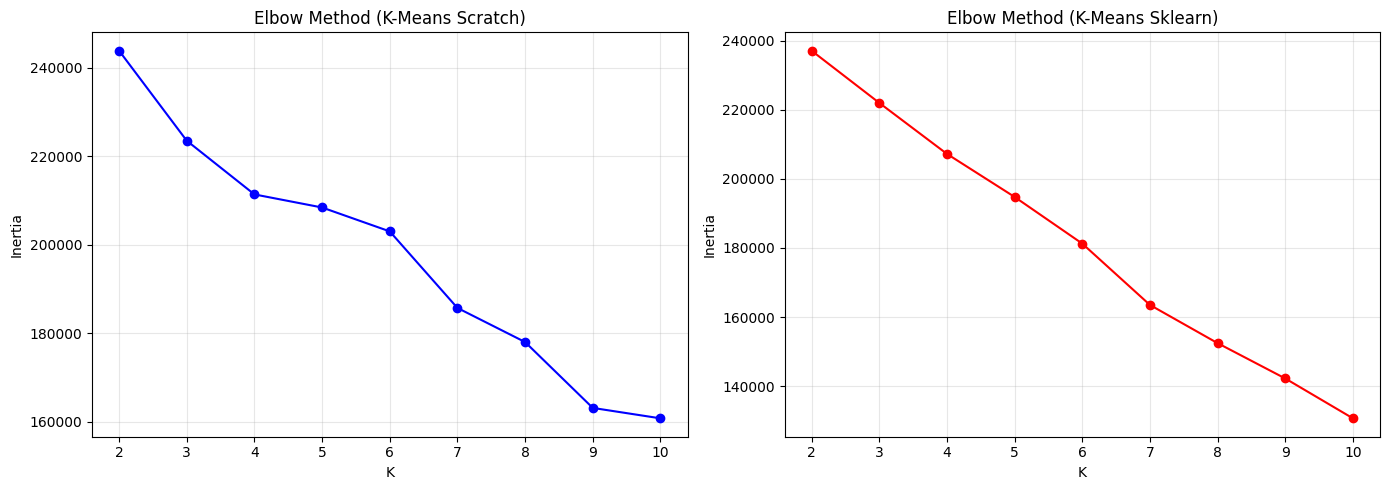

In [31]:
# Elbow method to find optimal K
inertias_scratch = []
inertias_sk = []
K_range = range(2, 11)

for k in K_range:
    km_s = KMeansScratch(n_clusters=k, random_state=42)
    km_s.fit(X_scaled)
    inertias_scratch.append(km_s.inertia_)
    
    km_sk = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    km_sk.fit(X_scaled)
    inertias_sk.append(km_sk.inertia_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias_scratch, 'bo-')
axes[0].set_title('Elbow Method (K-Means Scratch)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, inertias_sk, 'ro-')
axes[1].set_title('Elbow Method (K-Means Sklearn)')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Inertia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Agglomerative Clustering

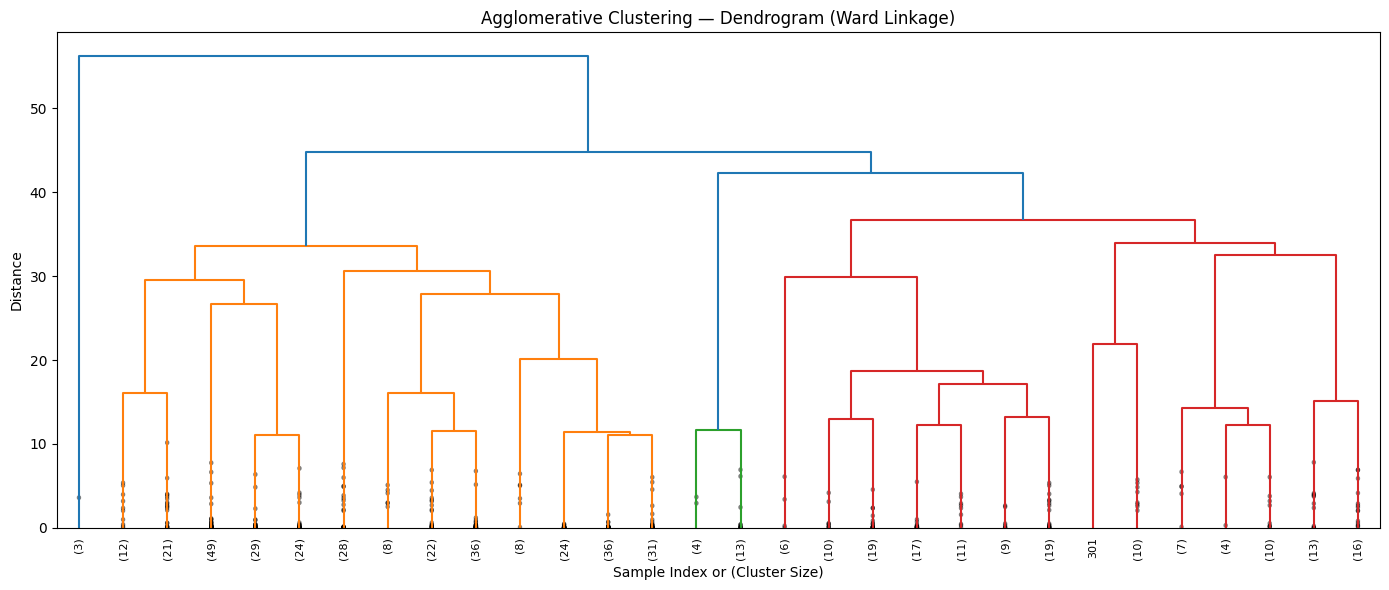

In [32]:
# Use a random subset for dendrogram visualization (full dataset is too large)
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(500, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

linked = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=8, show_contracted=True)
plt.title('Agglomerative Clustering — Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

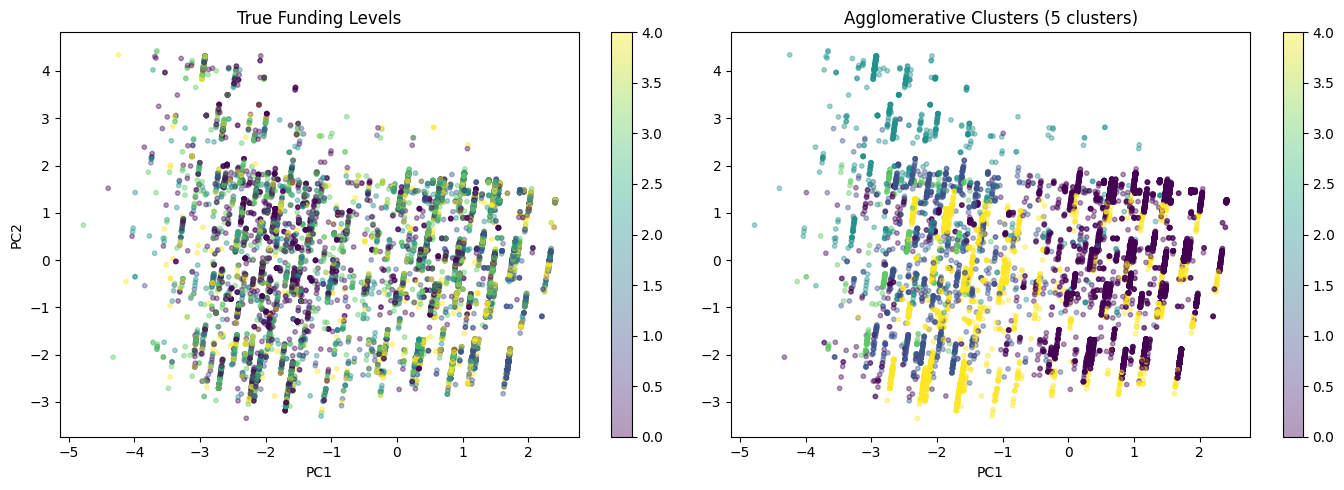

In [33]:
# Agglomerative clustering with 5 clusters
agg_clf = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg_clf.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter0 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], c=y_int.values, cmap='viridis', alpha=0.4, s=10)
axes[0].set_title('True Funding Levels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter0, ax=axes[0])

scatter1 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels, cmap='viridis', alpha=0.4, s=10)
axes[1].set_title('Agglomerative Clusters (5 clusters)')
axes[1].set_xlabel('PC1')
plt.colorbar(scatter1, ax=axes[1])

plt.tight_layout()
plt.show()

==========

Perceptron & Single-layer perceptron (SLP)

==========

- From Scratch (One-vs-Rest)

In [34]:
class PerceptronScratch:

    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.biases = None
        self.n_classes = None
        self.accuracy_history = []

    def _step_function(self, x):
        return np.where(x >= 0, 1, 0)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n_samples, n_features = X.shape
        self.n_classes = len(np.unique(y))

        self.weights = np.zeros((self.n_classes, n_features))
        self.biases = np.zeros(self.n_classes)
        self.accuracy_history = []

        for epoch in range(self.n_iters):
            for cls in range(self.n_classes):
                y_binary = (y == cls).astype(int)

                linear_output = X.dot(self.weights[cls]) + self.biases[cls]
                y_pred = self._step_function(linear_output)

                error = y_binary - y_pred
                self.weights[cls] += self.lr * X.T.dot(error) / n_samples
                self.biases[cls] += self.lr * np.sum(error) / n_samples

            if epoch % 50 == 0:
                y_pred_all = self.predict(X)
                acc = np.mean(y_pred_all == y)
                self.accuracy_history.append(acc)

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        scores = X.dot(self.weights.T) + self.biases
        return np.argmax(scores, axis=1)


  Perceptron / SLP (Scratch)
  Accuracy:              0.3271
  Precision (weighted):  0.2975
  Recall/Sensitivity:    0.3271
  Specificity (TNR):     0.8318
  F1-Score (weighted):   0.2469

Classification Report:
              precision    recall  f1-score   support

        high       0.44      0.70      0.54       460
         low       0.12      0.03      0.04       461
         mid       0.25      0.07      0.10       459
    mid-high       0.41      0.08      0.14       460
     mid-low       0.28      0.76      0.41       459

    accuracy                           0.33      2299
   macro avg       0.30      0.33      0.25      2299
weighted avg       0.30      0.33      0.25      2299



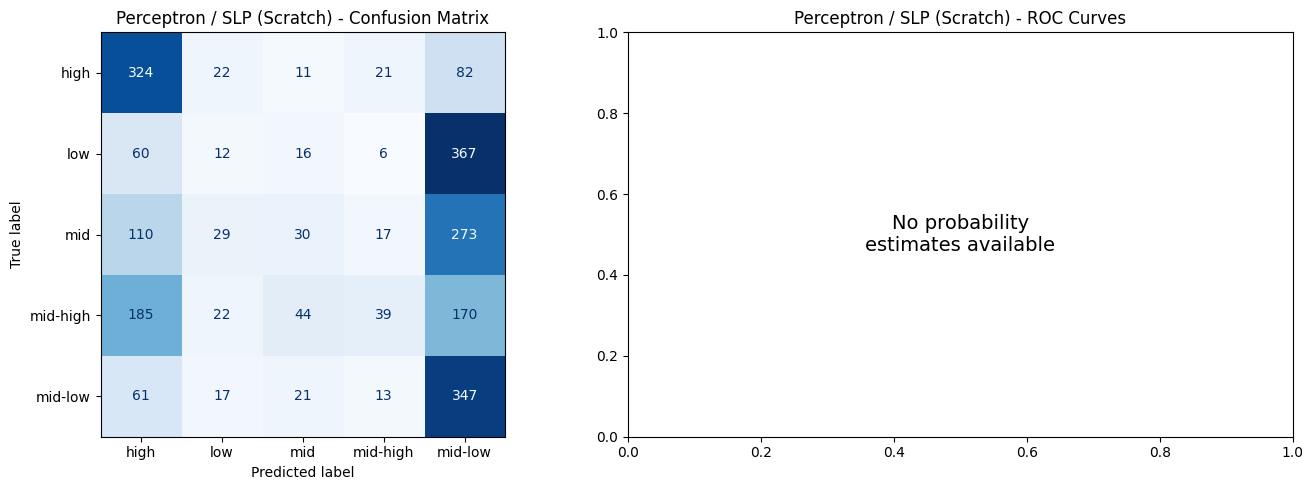

{'Accuracy': 0.3270987385819922,
 'Precision': 0.2974920351396011,
 'Recall (Sensitivity)': 0.3270987385819922,
 'Specificity (TNR)': np.float64(0.8318092241806431),
 'F1-Score': 0.24688385320818568,
 'ROC-AUC': None}

In [35]:
perceptron_scratch = PerceptronScratch(lr=0.01, n_iters=2000)
perceptron_scratch.fit(X_train, y_train)

y_pred_perceptron = perceptron_scratch.predict(X_test)

evaluate_model("Perceptron / SLP (Scratch)", y_test, y_pred_perceptron)

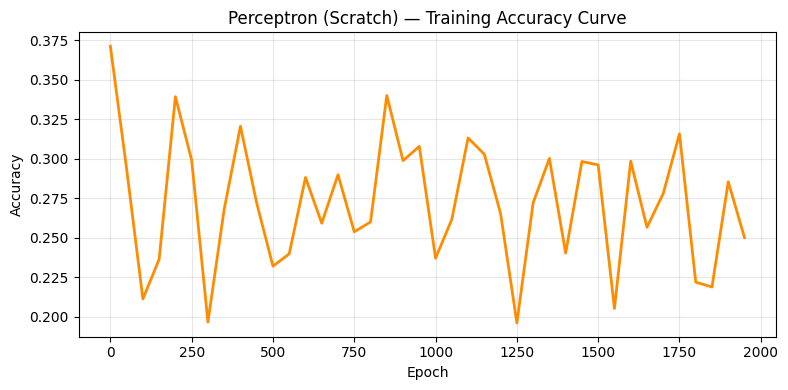

In [36]:
# Accuracy curve
plt.figure(figsize=(8, 4))
plt.plot(range(0, len(perceptron_scratch.accuracy_history) * 50, 50),
         perceptron_scratch.accuracy_history, color='darkorange', linewidth=2)
plt.title('Perceptron (Scratch) — Training Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Using sklearn lib


  Perceptron (Sklearn)
  Accuracy:              0.3023
  Precision (weighted):  0.3041
  Recall/Sensitivity:    0.3023
  Specificity (TNR):     0.8256
  F1-Score (weighted):   0.3009

Classification Report:
              precision    recall  f1-score   support

        high       0.27      0.35      0.31       460
         low       0.41      0.40      0.41       461
         mid       0.21      0.17      0.19       459
    mid-high       0.28      0.30      0.29       460
     mid-low       0.36      0.29      0.32       459

    accuracy                           0.30      2299
   macro avg       0.30      0.30      0.30      2299
weighted avg       0.30      0.30      0.30      2299



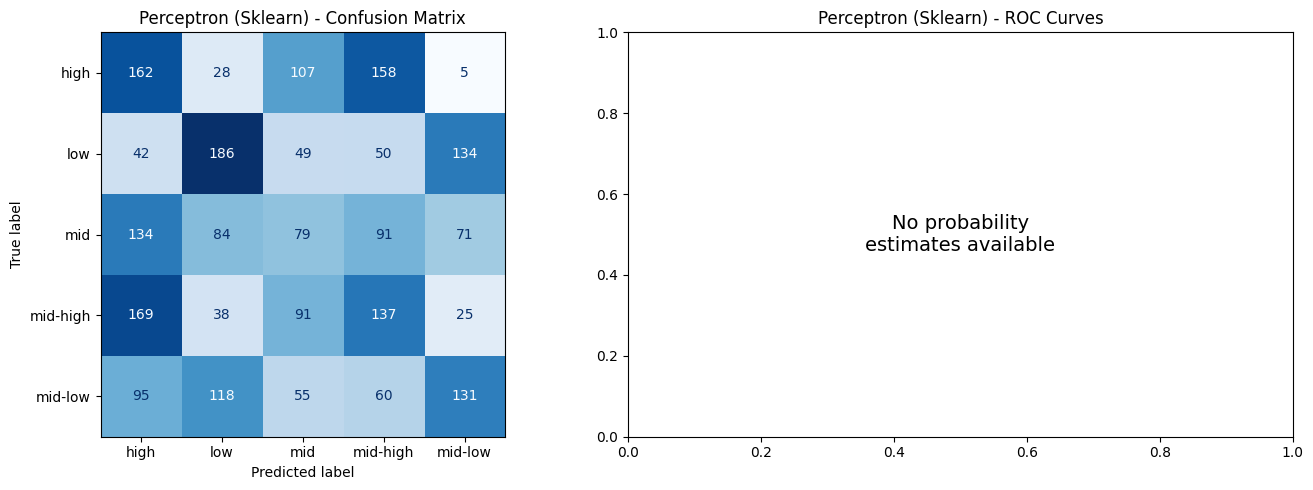

{'Accuracy': 0.3023053501522401,
 'Precision': 0.3041199573859224,
 'Recall (Sensitivity)': 0.3023053501522401,
 'Specificity (TNR)': np.float64(0.8255732503711062),
 'F1-Score': 0.3008725206905642,
 'ROC-AUC': None}

In [37]:
sk_perceptron = Perceptron(max_iter=100, eta0=0.01, random_state=42)
sk_perceptron.fit(X_train, y_train)

y_pred_sk_perceptron = sk_perceptron.predict(X_test)

evaluate_model("Perceptron (Sklearn)", y_test, y_pred_sk_perceptron)

==========

Multi-layer perceptron (MLP)

==========

- From Scratch (1 Hidden Layer, ReLU + Softmax)

In [38]:
class MLPScratch:

    def __init__(self, hidden_size=64, lr=0.01, n_iters=1000):
        self.hidden_size = hidden_size
        self.lr = lr
        self.n_iters = n_iters
        self.loss_history = []
        self.accuracy_history = []

    @staticmethod
    def _relu(Z):
        return np.maximum(0, Z)

    @staticmethod
    def _relu_deriv(Z):
        return (Z > 0).astype(float)

    @staticmethod
    def _softmax(Z):
        Z_shift = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shift)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    @staticmethod
    def _one_hot(y, num_classes):
        N = y.shape[0]
        oh = np.zeros((N, num_classes))
        oh[np.arange(N), y] = 1
        return oh

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        N, d = X.shape
        K = len(np.unique(y))

        # He initialization
        np.random.seed(42)
        self.W1 = np.random.randn(d, self.hidden_size) * np.sqrt(2.0 / d)
        self.b1 = np.zeros((1, self.hidden_size))
        self.W2 = np.random.randn(self.hidden_size, K) * np.sqrt(2.0 / self.hidden_size)
        self.b2 = np.zeros((1, K))

        y_oh = self._one_hot(y, K)
        self.loss_history = []
        self.accuracy_history = []

        for i in range(self.n_iters):
            # Forward pass
            Z1 = X.dot(self.W1) + self.b1
            A1 = self._relu(Z1)
            Z2 = A1.dot(self.W2) + self.b2
            A2 = self._softmax(Z2)

            loss = -np.mean(np.sum(y_oh * np.log(np.clip(A2, 1e-12, 1.0)), axis=1))

            # Backpropagation
            dZ2 = (A2 - y_oh) / N
            dW2 = A1.T.dot(dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = dZ2.dot(self.W2.T)
            dZ1 = dA1 * self._relu_deriv(Z1)
            dW1 = X.T.dot(dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1

            if i % 50 == 0:
                self.loss_history.append(loss)
                acc = np.mean(np.argmax(A2, axis=1) == y)
                self.accuracy_history.append(acc)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        Z1 = X.dot(self.W1) + self.b1
        A1 = self._relu(Z1)
        Z2 = A1.dot(self.W2) + self.b2
        return self._softmax(Z2)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


  MLP (Scratch)
  Accuracy:              0.4241
  Precision (weighted):  0.4085
  Recall/Sensitivity:    0.4241
  Specificity (TNR):     0.8560
  F1-Score (weighted):   0.4047
  ROC-AUC (macro):       0.7459

Classification Report:
              precision    recall  f1-score   support

        high       0.53      0.63      0.57       460
         low       0.47      0.66      0.55       461
         mid       0.28      0.16      0.20       459
    mid-high       0.34      0.41      0.37       460
     mid-low       0.43      0.26      0.33       459

    accuracy                           0.42      2299
   macro avg       0.41      0.42      0.40      2299
weighted avg       0.41      0.42      0.40      2299



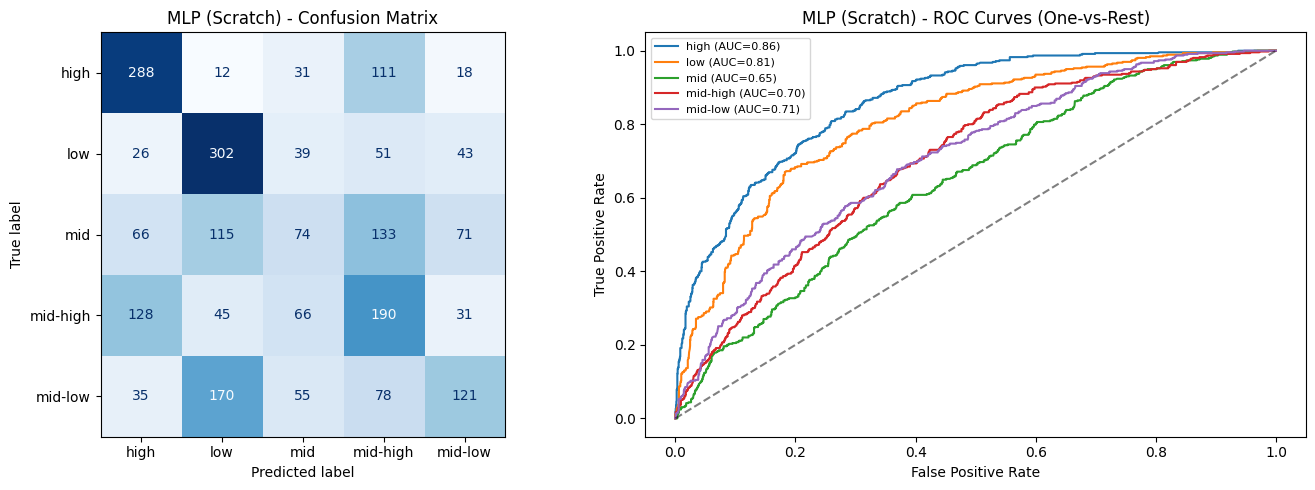

{'Accuracy': 0.42409743366681163,
 'Precision': 0.40849689485988194,
 'Recall (Sensitivity)': 0.42409743366681163,
 'Specificity (TNR)': np.float64(0.8560093876549381),
 'F1-Score': 0.40467640905983265,
 'ROC-AUC': 0.7458502336827577}

In [39]:
mlp_scratch = MLPScratch(hidden_size=256, lr=0.01, n_iters=5000)
mlp_scratch.fit(X_train, y_train)

y_pred_mlp = mlp_scratch.predict(X_test)
y_proba_mlp = mlp_scratch.predict_proba(X_test)

evaluate_model("MLP (Scratch)", y_test, y_pred_mlp, y_proba_mlp)

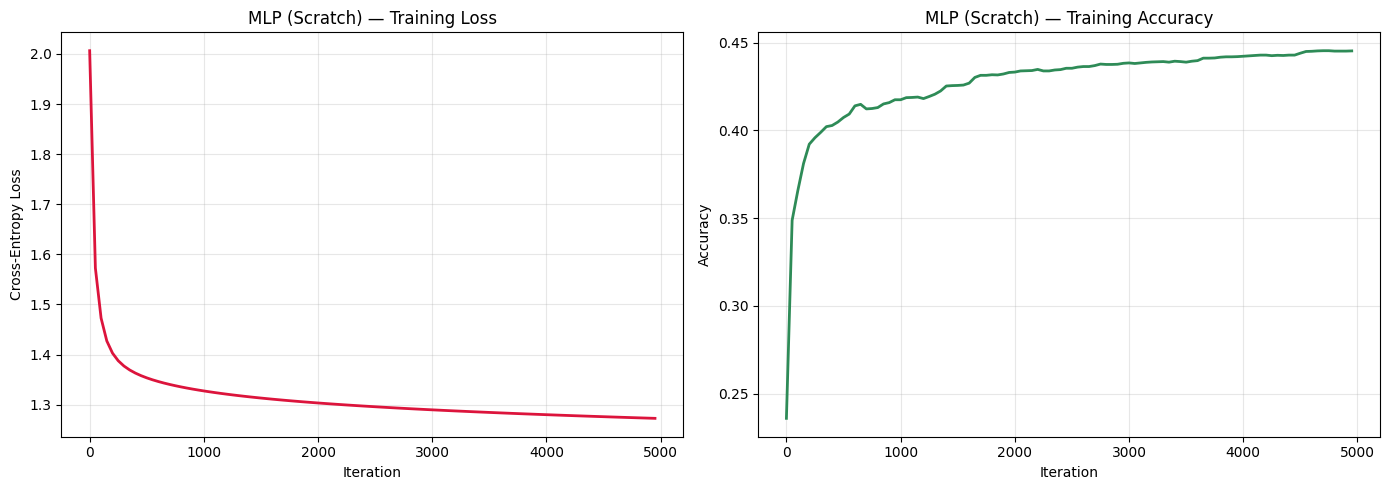

In [40]:
# Loss & Accuracy curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = range(0, len(mlp_scratch.loss_history) * 50, 50)
axes[0].plot(iters, mlp_scratch.loss_history, color='crimson', linewidth=2)
axes[0].set_title('MLP (Scratch) — Training Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(iters, mlp_scratch.accuracy_history, color='seagreen', linewidth=2)
axes[1].set_title('MLP (Scratch) — Training Accuracy')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Using sklearn lib


  MLP (Sklearn)
  Accuracy:              0.4280
  Precision (weighted):  0.4094
  Recall/Sensitivity:    0.4280
  Specificity (TNR):     0.8570
  F1-Score (weighted):   0.4116
  ROC-AUC (macro):       0.7506

Classification Report:
              precision    recall  f1-score   support

        high       0.55      0.61      0.58       460
         low       0.50      0.63      0.56       461
         mid       0.26      0.14      0.18       459
    mid-high       0.34      0.43      0.38       460
     mid-low       0.40      0.34      0.36       459

    accuracy                           0.43      2299
   macro avg       0.41      0.43      0.41      2299
weighted avg       0.41      0.43      0.41      2299



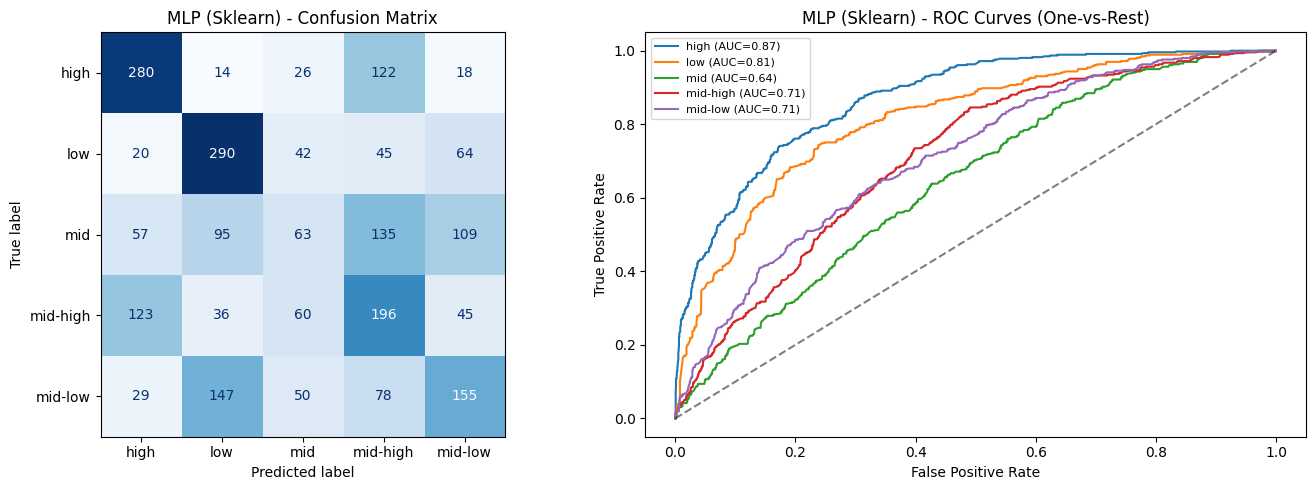

{'Accuracy': 0.42801217920835144,
 'Precision': 0.40940623827954264,
 'Recall (Sensitivity)': 0.42801217920835144,
 'Specificity (TNR)': np.float64(0.8569946853360362),
 'F1-Score': 0.41160147490048943,
 'ROC-AUC': 0.7506151584304288}

In [41]:
sk_mlp = MLPClassifier(
    hidden_layer_sizes=(64,), activation='relu',
    max_iter=300, alpha=0.01, random_state=42
)
sk_mlp.fit(X_train, y_train)

y_pred_sk_mlp = sk_mlp.predict(X_test)
y_proba_sk_mlp = sk_mlp.predict_proba(X_test)

evaluate_model("MLP (Sklearn)", y_test, y_pred_sk_mlp, y_proba_sk_mlp)

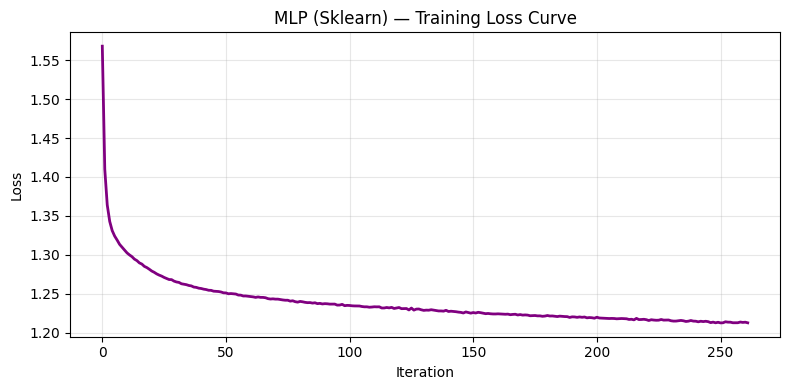

In [42]:
# Sklearn MLP loss curve
plt.figure(figsize=(8, 4))
plt.plot(sk_mlp.loss_curve_, color='purple', linewidth=2)
plt.title('MLP (Sklearn) — Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

==========

A better and extracurricular classification model (mandatory)

==========

- Gradient Boosting from Scratch

In [43]:
from sklearn.tree import DecisionTreeRegressor


class GradientBoostingClassifierScratch:

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state
        self.trees = {}
        self.n_classes = None
        self.loss_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.n_classes = len(np.unique(y))
        N = X.shape[0]

        raw_scores = {cls: np.zeros(N) for cls in range(self.n_classes)}
        self.trees = {cls: [] for cls in range(self.n_classes)}
        self.loss_history = []

        for i in range(self.n_estimators):
            total_loss = 0
            for cls in range(self.n_classes):
                y_binary = (y == cls).astype(float)
                probs = self._sigmoid(raw_scores[cls])
                residuals = y_binary - probs

                tree = DecisionTreeRegressor(
                    max_depth=self.max_depth, random_state=self.random_state
                )
                tree.fit(X, residuals)

                raw_scores[cls] += self.learning_rate * tree.predict(X)
                self.trees[cls].append(tree)

                probs_clipped = np.clip(probs, 1e-12, 1 - 1e-12)
                total_loss += -np.mean(
                    y_binary * np.log(probs_clipped) +
                    (1 - y_binary) * np.log(1 - probs_clipped)
                )

            if i % 10 == 0:
                self.loss_history.append(total_loss / self.n_classes)

    def _predict_raw(self, X):
        X = np.asarray(X, dtype=float)
        N = X.shape[0]
        raw_scores = np.zeros((N, self.n_classes))
        for cls in range(self.n_classes):
            for tree in self.trees[cls]:
                raw_scores[:, cls] += self.learning_rate * tree.predict(X)
        return raw_scores

    def predict_proba(self, X):
        raw = self._predict_raw(X)
        raw_shift = raw - np.max(raw, axis=1, keepdims=True)
        exp_raw = np.exp(raw_shift)
        return exp_raw / np.sum(exp_raw, axis=1, keepdims=True)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


  Gradient Boosting (Scratch)
  Accuracy:              0.4472
  Precision (weighted):  0.4351
  Recall/Sensitivity:    0.4472
  Specificity (TNR):     0.8618
  F1-Score (weighted):   0.4368
  ROC-AUC (macro):       0.7756

Classification Report:
              precision    recall  f1-score   support

        high       0.58      0.66      0.62       460
         low       0.54      0.61      0.57       461
         mid       0.31      0.22      0.26       459
    mid-high       0.35      0.43      0.39       460
     mid-low       0.40      0.31      0.35       459

    accuracy                           0.45      2299
   macro avg       0.43      0.45      0.44      2299
weighted avg       0.44      0.45      0.44      2299



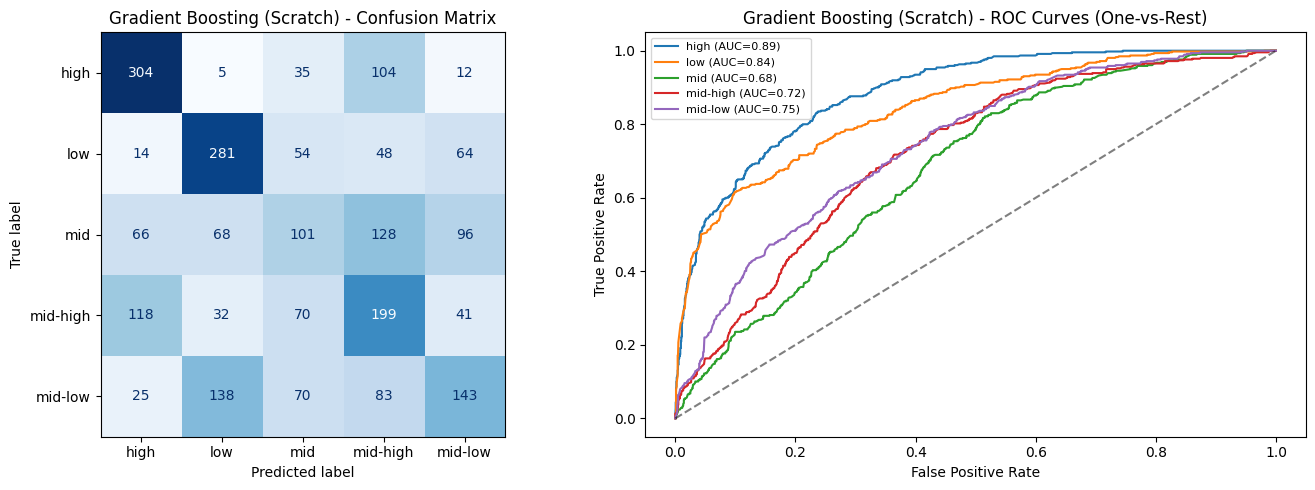

{'Accuracy': 0.44715093518921273,
 'Precision': 0.43510424900532485,
 'Recall (Sensitivity)': 0.44715093518921273,
 'Specificity (TNR)': np.float64(0.8617844489905995),
 'F1-Score': 0.4367619762979488,
 'ROC-AUC': 0.7756238271303733}

In [44]:
gb_scratch = GradientBoostingClassifierScratch(
    n_estimators=300, learning_rate=0.1, max_depth=5, random_state=42
)
gb_scratch.fit(X_train, y_train)

y_pred_gb = gb_scratch.predict(X_test)
y_proba_gb = gb_scratch.predict_proba(X_test)

evaluate_model("Gradient Boosting (Scratch)", y_test, y_pred_gb, y_proba_gb)

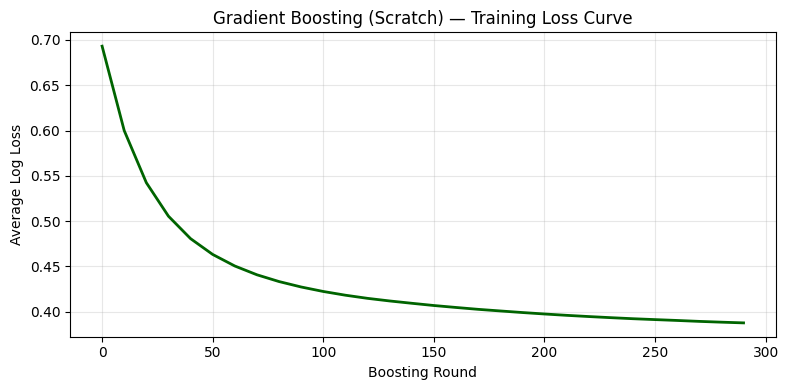

In [45]:
# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(range(0, len(gb_scratch.loss_history) * 10, 10),
         gb_scratch.loss_history, color='darkgreen', linewidth=2)
plt.title('Gradient Boosting (Scratch) — Training Loss Curve')
plt.xlabel('Boosting Round')
plt.ylabel('Average Log Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

- Using sklearn lib


  Gradient Boosting (Sklearn)
  Accuracy:              0.4350
  Precision (weighted):  0.4156
  Recall/Sensitivity:    0.4350
  Specificity (TNR):     0.8587
  F1-Score (weighted):   0.4134
  ROC-AUC (macro):       0.7556

Classification Report:
              precision    recall  f1-score   support

        high       0.52      0.70      0.60       460
         low       0.47      0.58      0.52       461
         mid       0.30      0.14      0.19       459
    mid-high       0.36      0.43      0.39       460
     mid-low       0.42      0.33      0.37       459

    accuracy                           0.43      2299
   macro avg       0.42      0.43      0.41      2299
weighted avg       0.42      0.43      0.41      2299



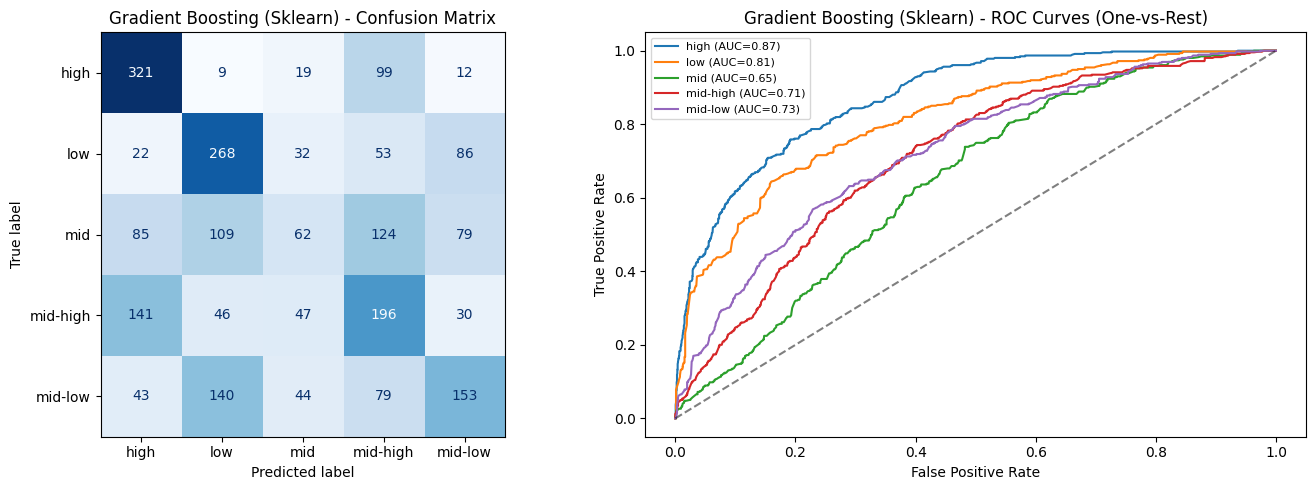

{'Accuracy': 0.43497172683775553,
 'Precision': 0.4156034279522681,
 'Recall (Sensitivity)': 0.43497172683775553,
 'Specificity (TNR)': np.float64(0.8587302095423823),
 'F1-Score': 0.41339109118010087,
 'ROC-AUC': 0.7555801159430674}

In [46]:
sk_gb = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42
)
sk_gb.fit(X_train, y_train)

y_pred_sk_gb = sk_gb.predict(X_test)
y_proba_sk_gb = sk_gb.predict_proba(X_test)

evaluate_model("Gradient Boosting (Sklearn)", y_test, y_pred_sk_gb, y_proba_sk_gb)

==========

Model Comparison & Benchmarking

==========

In [47]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('Accuracy', ascending=False)

print("\n" + "=" * 80)
print("  MODEL BENCHMARKING — ALL CLASSIFICATION MODELS")
print("=" * 80)
print(results_df.to_string())


  MODEL BENCHMARKING — ALL CLASSIFICATION MODELS
                               Accuracy  Precision  Recall (Sensitivity)  Specificity (TNR)  F1-Score   ROC-AUC
Decision Tree (Scratch)        0.467595   0.462835              0.467595           0.866901  0.463260       NaN
Random Forest + PCA            0.451066   0.446613              0.451066           0.862773  0.448409  0.744553
Random Forest (Sklearn)        0.448891   0.430476              0.448891           0.862211  0.429037  0.765058
Gradient Boosting (Scratch)    0.447151   0.435104              0.447151           0.861784  0.436762  0.775624
Decision Tree (Sklearn)        0.442366   0.450088              0.442366           0.860602  0.442006  0.757945
Gradient Boosting (Sklearn)    0.434972   0.415603              0.434972           0.858730  0.413391  0.755580
MLP (Sklearn)                  0.428012   0.409406              0.428012           0.856995  0.411601  0.750615
MLP (Scratch)                  0.424097   0.408497    

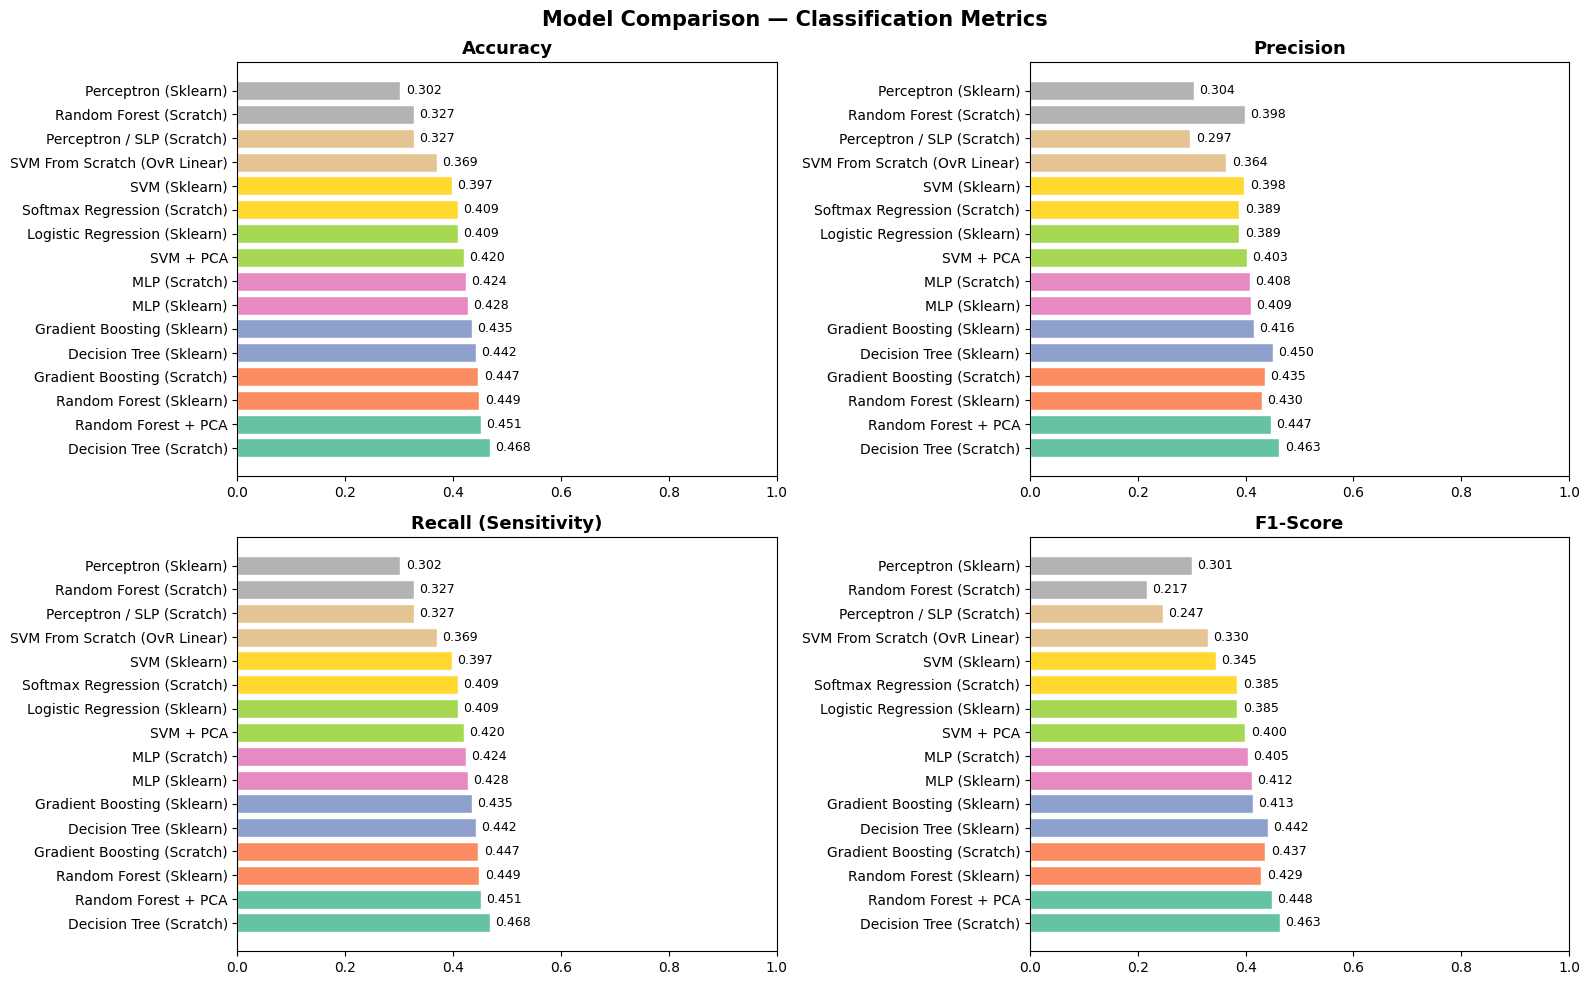

In [48]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score']
colors = plt.cm.Set2(np.linspace(0, 1, len(results_df)))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    values = results_df[metric].values
    bars = ax.barh(results_df.index, values, color=colors, edgecolor='white')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison — Classification Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

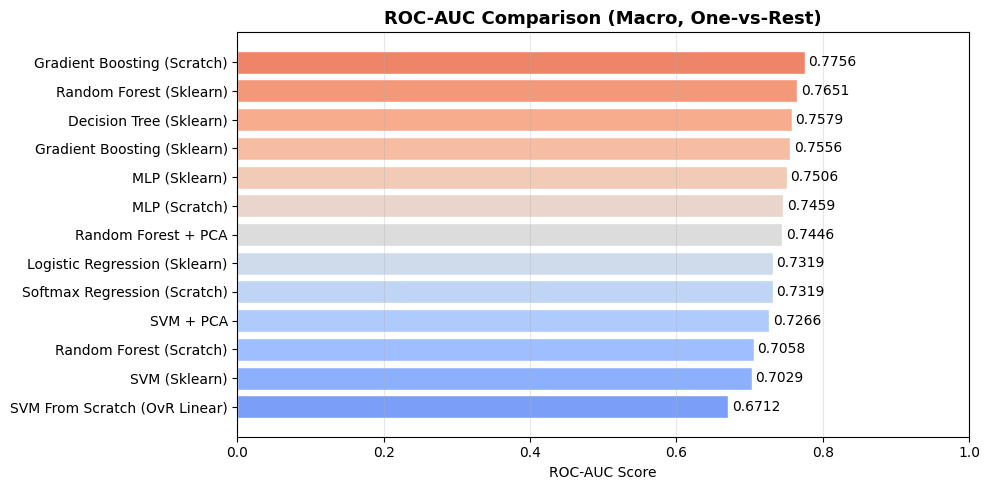

In [49]:
# ROC-AUC comparison (only models with AUC)
auc_df = results_df.dropna(subset=['ROC-AUC']).sort_values('ROC-AUC', ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.barh(auc_df.index, auc_df['ROC-AUC'],
                color=plt.cm.coolwarm(np.linspace(0.2, 0.8, len(auc_df))),
                edgecolor='white')
for bar, val in zip(bars, auc_df['ROC-AUC']):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', fontsize=10)
plt.title('ROC-AUC Comparison (Macro, One-vs-Rest)', fontsize=13, fontweight='bold')
plt.xlabel('ROC-AUC Score')
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

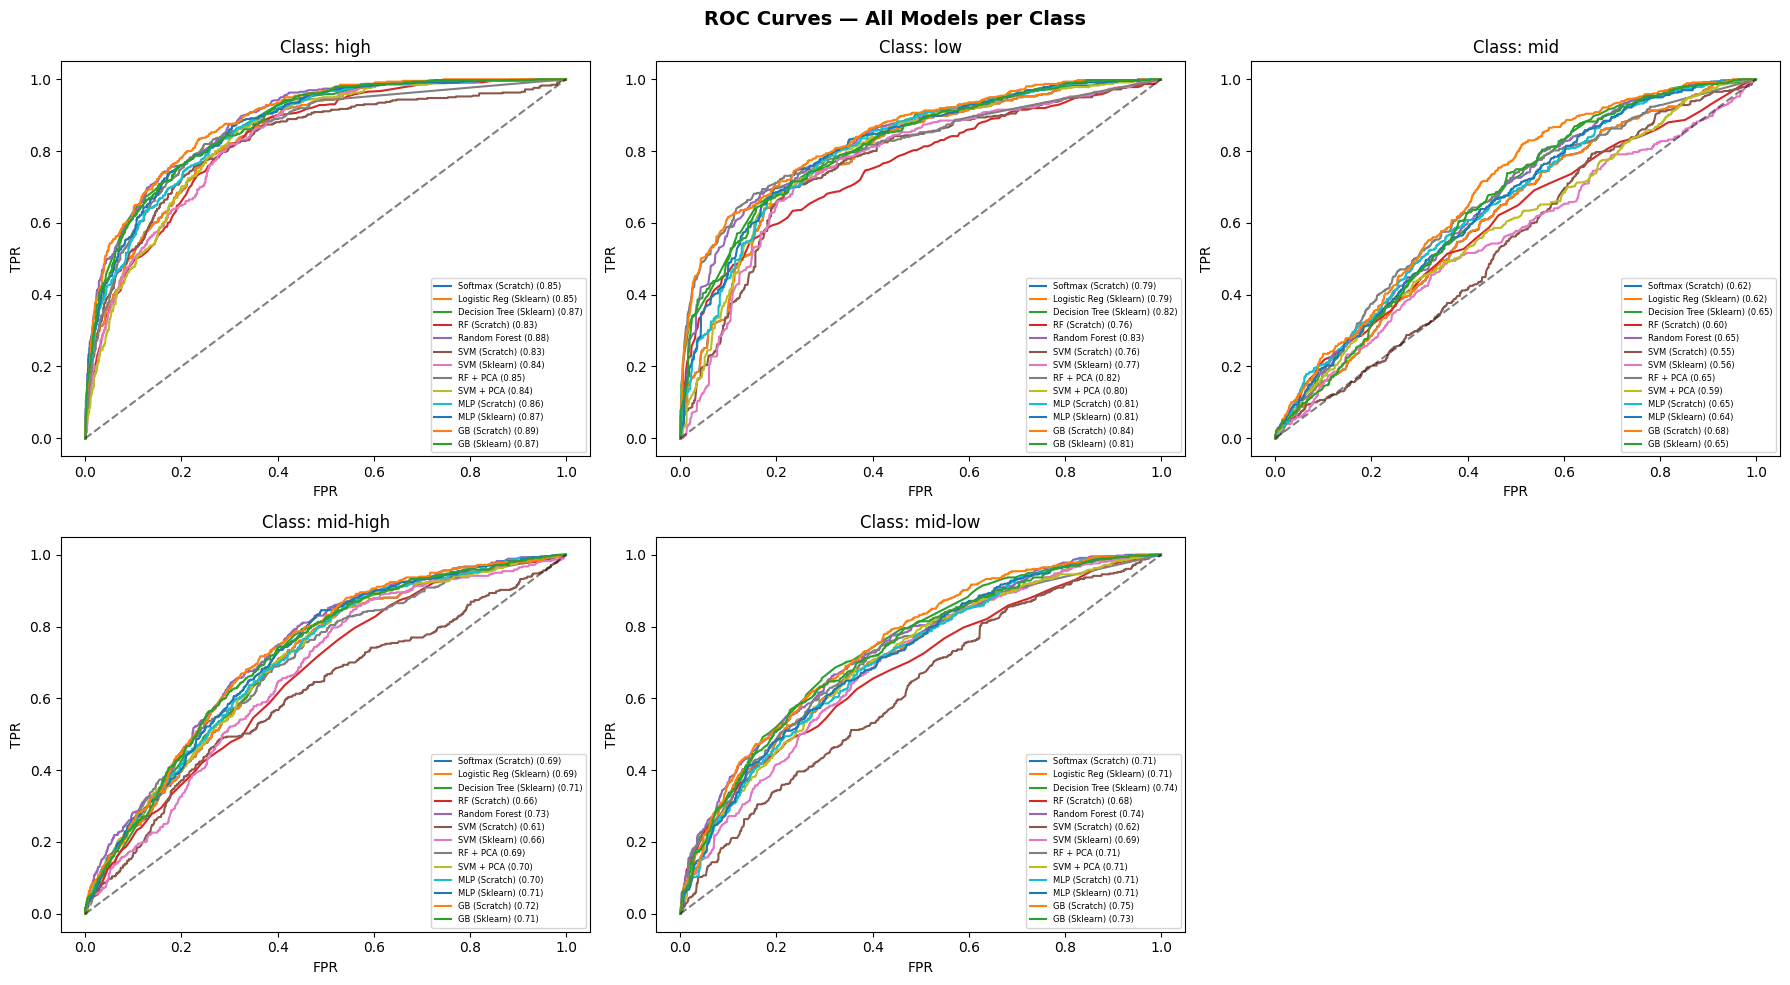

In [50]:
# Combined ROC curves for all models with probability estimates
models_with_proba = {
    'Softmax (Scratch)': y_proba_softmax,
    'Logistic Reg (Sklearn)': y_proba_sklr,
    'Decision Tree (Sklearn)': y_proba_skdt,
    'RF (Scratch)': y_proba_rf_scratch,
    'Random Forest': y_proba_rf,
    'SVM (Scratch)': y_proba_svm_scratch,
    'SVM (Sklearn)': y_proba_svm,
    'RF + PCA': y_proba_rf_pca,
    'SVM + PCA': y_proba_svm_pca,
    'MLP (Scratch)': y_proba_mlp,
    'MLP (Sklearn)': y_proba_sk_mlp,
    'GB (Scratch)': y_proba_gb,
    'GB (Sklearn)': y_proba_sk_gb,
}

y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flat

for cls_idx in range(num_classes):
    ax = axes[cls_idx]
    for name, proba in models_with_proba.items():
        fpr, tpr, _ = roc_curve(y_test_bin[:, cls_idx], proba[:, cls_idx])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} ({roc_auc_val:.2f})', linewidth=1.5)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(f'Class: {class_names[cls_idx]}', fontsize=12)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=6, loc='lower right')

if num_classes < 6:
    axes[5].set_visible(False)

plt.suptitle('ROC Curves — All Models per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [51]:
# Final summary
print("\n" + "=" * 80)
print("  FINAL MODEL RANKING")
print("=" * 80)
print(results_df.to_string())
print("\nBest model by Accuracy:", results_df.index[0],
      f"({results_df['Accuracy'].iloc[0]:.4f})")
best_auc_name = auc_df.index[-1] if len(auc_df) > 0 else 'N/A'
best_auc_val = auc_df['ROC-AUC'].iloc[-1] if len(auc_df) > 0 else 0
print(f"Best model by ROC-AUC: {best_auc_name} ({best_auc_val:.4f})")


  FINAL MODEL RANKING
                               Accuracy  Precision  Recall (Sensitivity)  Specificity (TNR)  F1-Score   ROC-AUC
Decision Tree (Scratch)        0.467595   0.462835              0.467595           0.866901  0.463260       NaN
Random Forest + PCA            0.451066   0.446613              0.451066           0.862773  0.448409  0.744553
Random Forest (Sklearn)        0.448891   0.430476              0.448891           0.862211  0.429037  0.765058
Gradient Boosting (Scratch)    0.447151   0.435104              0.447151           0.861784  0.436762  0.775624
Decision Tree (Sklearn)        0.442366   0.450088              0.442366           0.860602  0.442006  0.757945
Gradient Boosting (Sklearn)    0.434972   0.415603              0.434972           0.858730  0.413391  0.755580
MLP (Sklearn)                  0.428012   0.409406              0.428012           0.856995  0.411601  0.750615
MLP (Scratch)                  0.424097   0.408497              0.424097         